In [1]:
import os
from utils.MOO_utilities import *

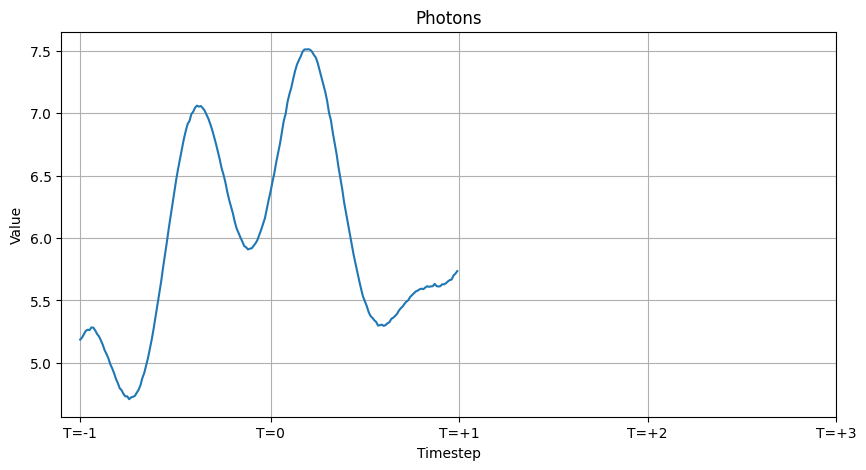

In [3]:
dr = DataReader("./data/Bundle2")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

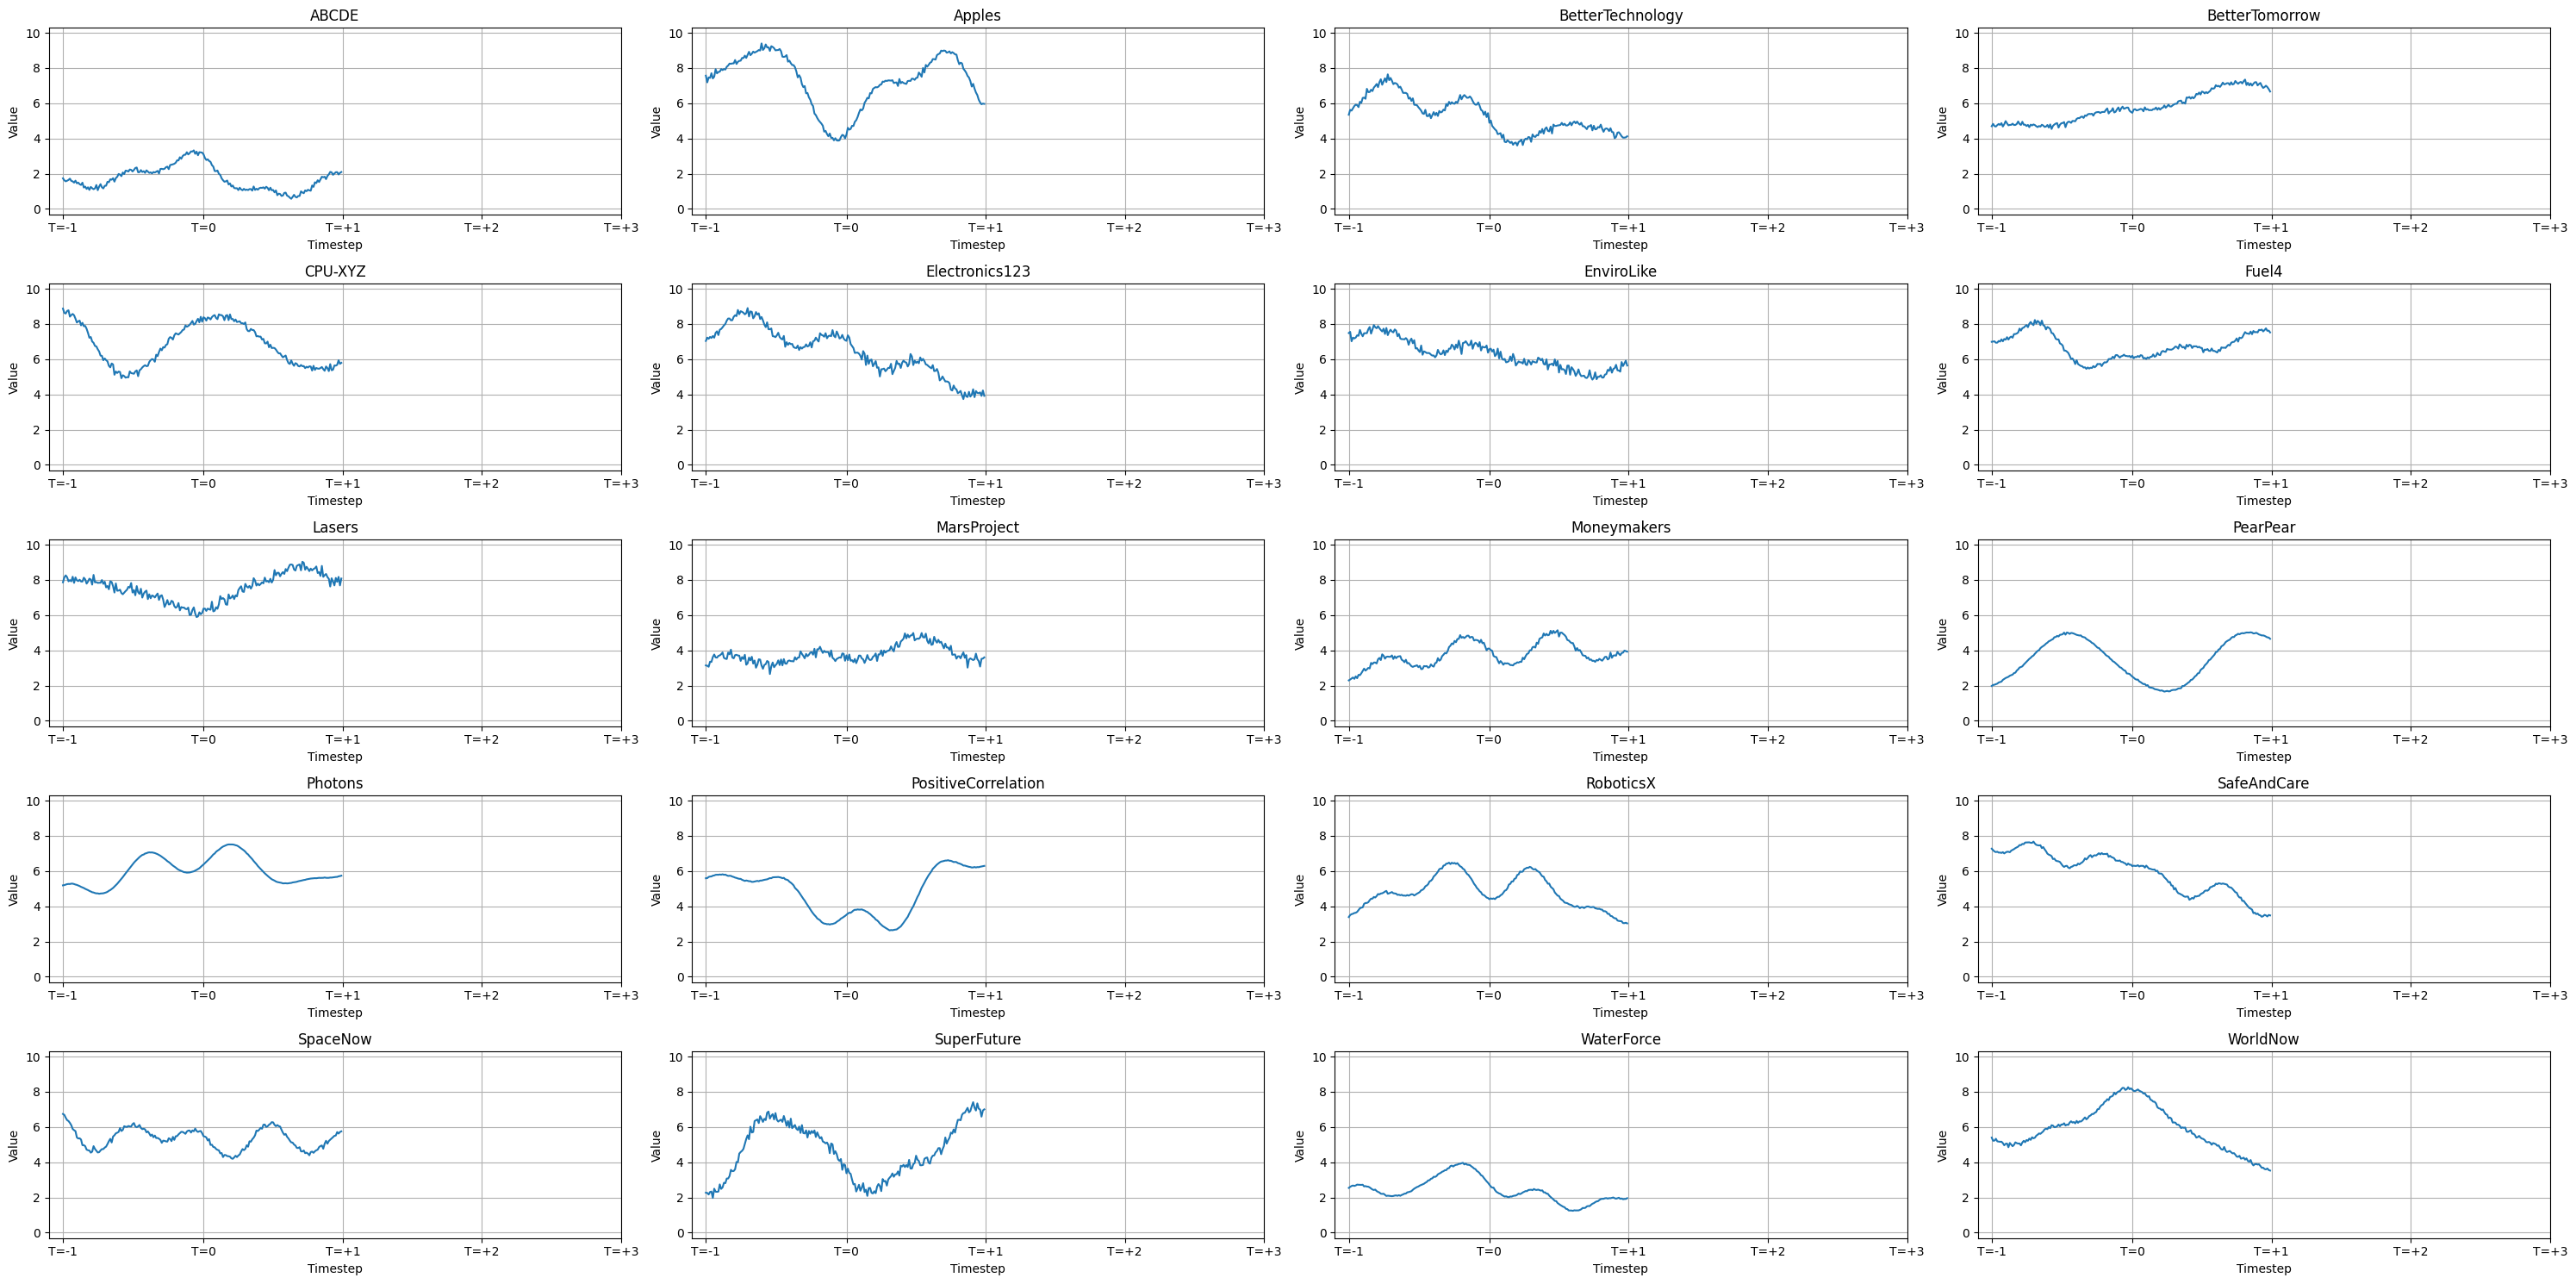

In [4]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

In [2]:
# Load all predictions and ground truth data
regression_models = ["Linear", "Sinusoidal", "Complex Sinusoidal", "ARIMA", "XGBoost", "NODE"]
base_dir = "./data/Predictions2"

loaded_data = {}
for model in regression_models:
    model_dir = os.path.join(base_dir, model)
    loaded_data[model] = {}

    for company in ORDER:
        company_dir = os.path.join(model_dir, company)
        indexes = np.load(os.path.join(company_dir, "indexes.npy"))
        predictions = np.load(os.path.join(company_dir, "predictions.npy"))
        loaded_data[model][company] = (indexes, predictions)

In [6]:
regression_predictions = []
for model in regression_models:
    regression_predictions.append(loaded_data[model])

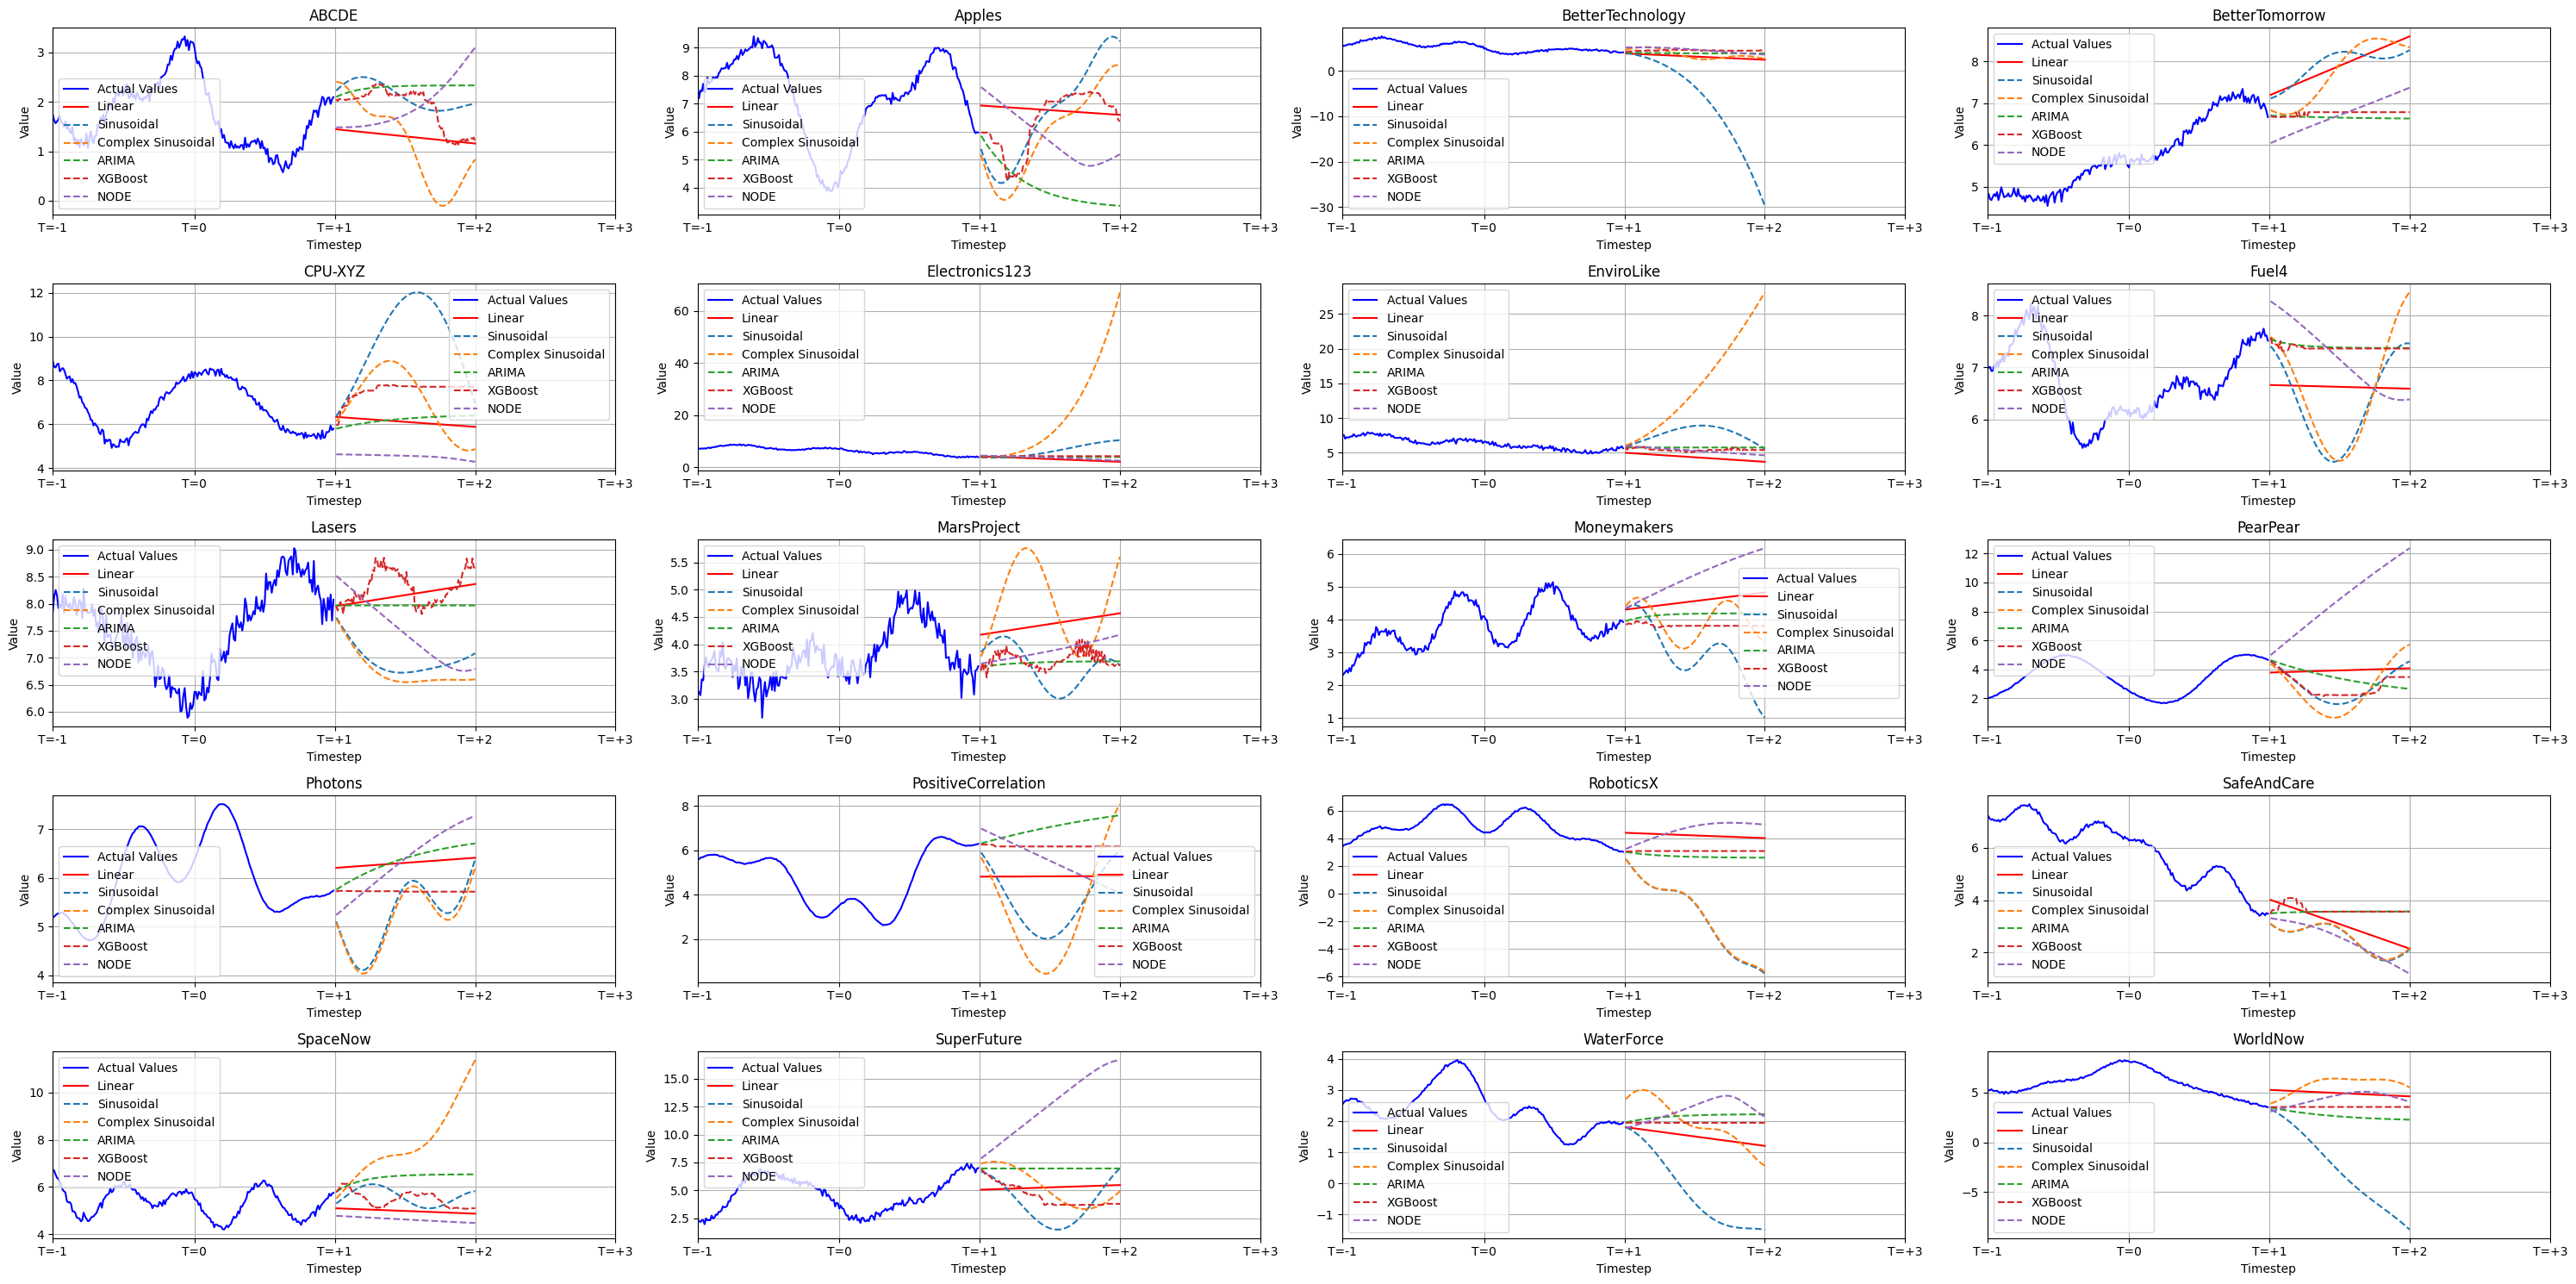

In [ ]:
RMC = RegressionModelsCombined(data, window_size=50)
RMC.plot_multiple_predictions(val_range=301, predictions_list=regression_predictions, 
                              figsize=(30, 15), titles=regression_models)


Linear


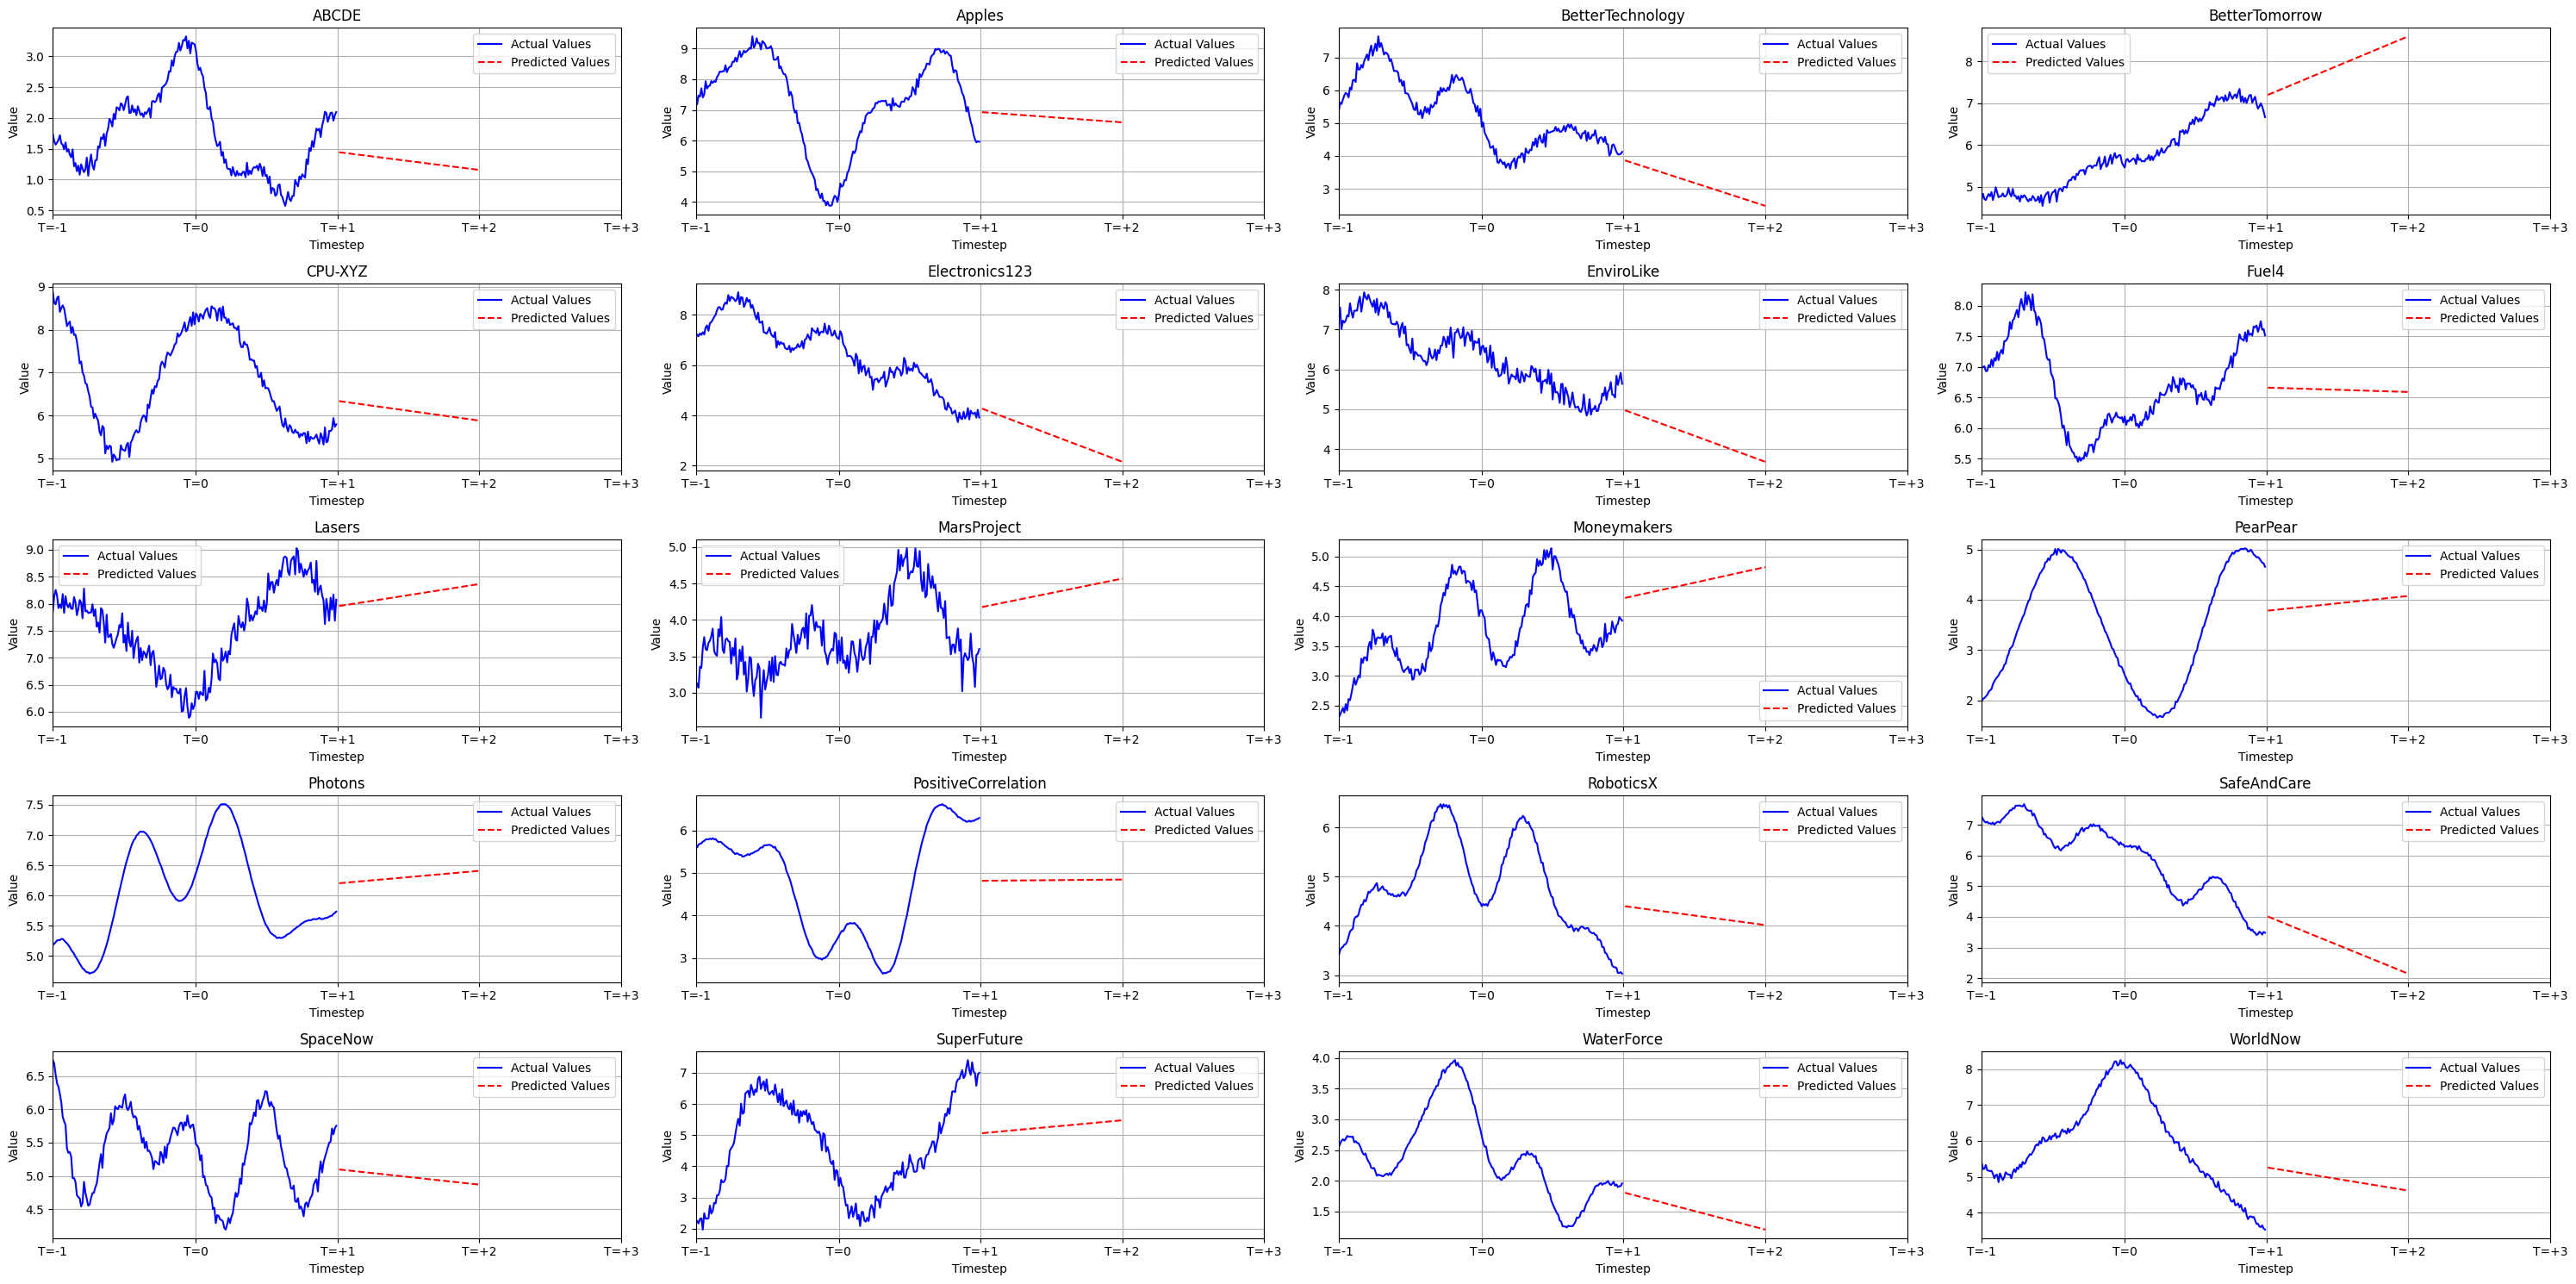

Sinusoidal


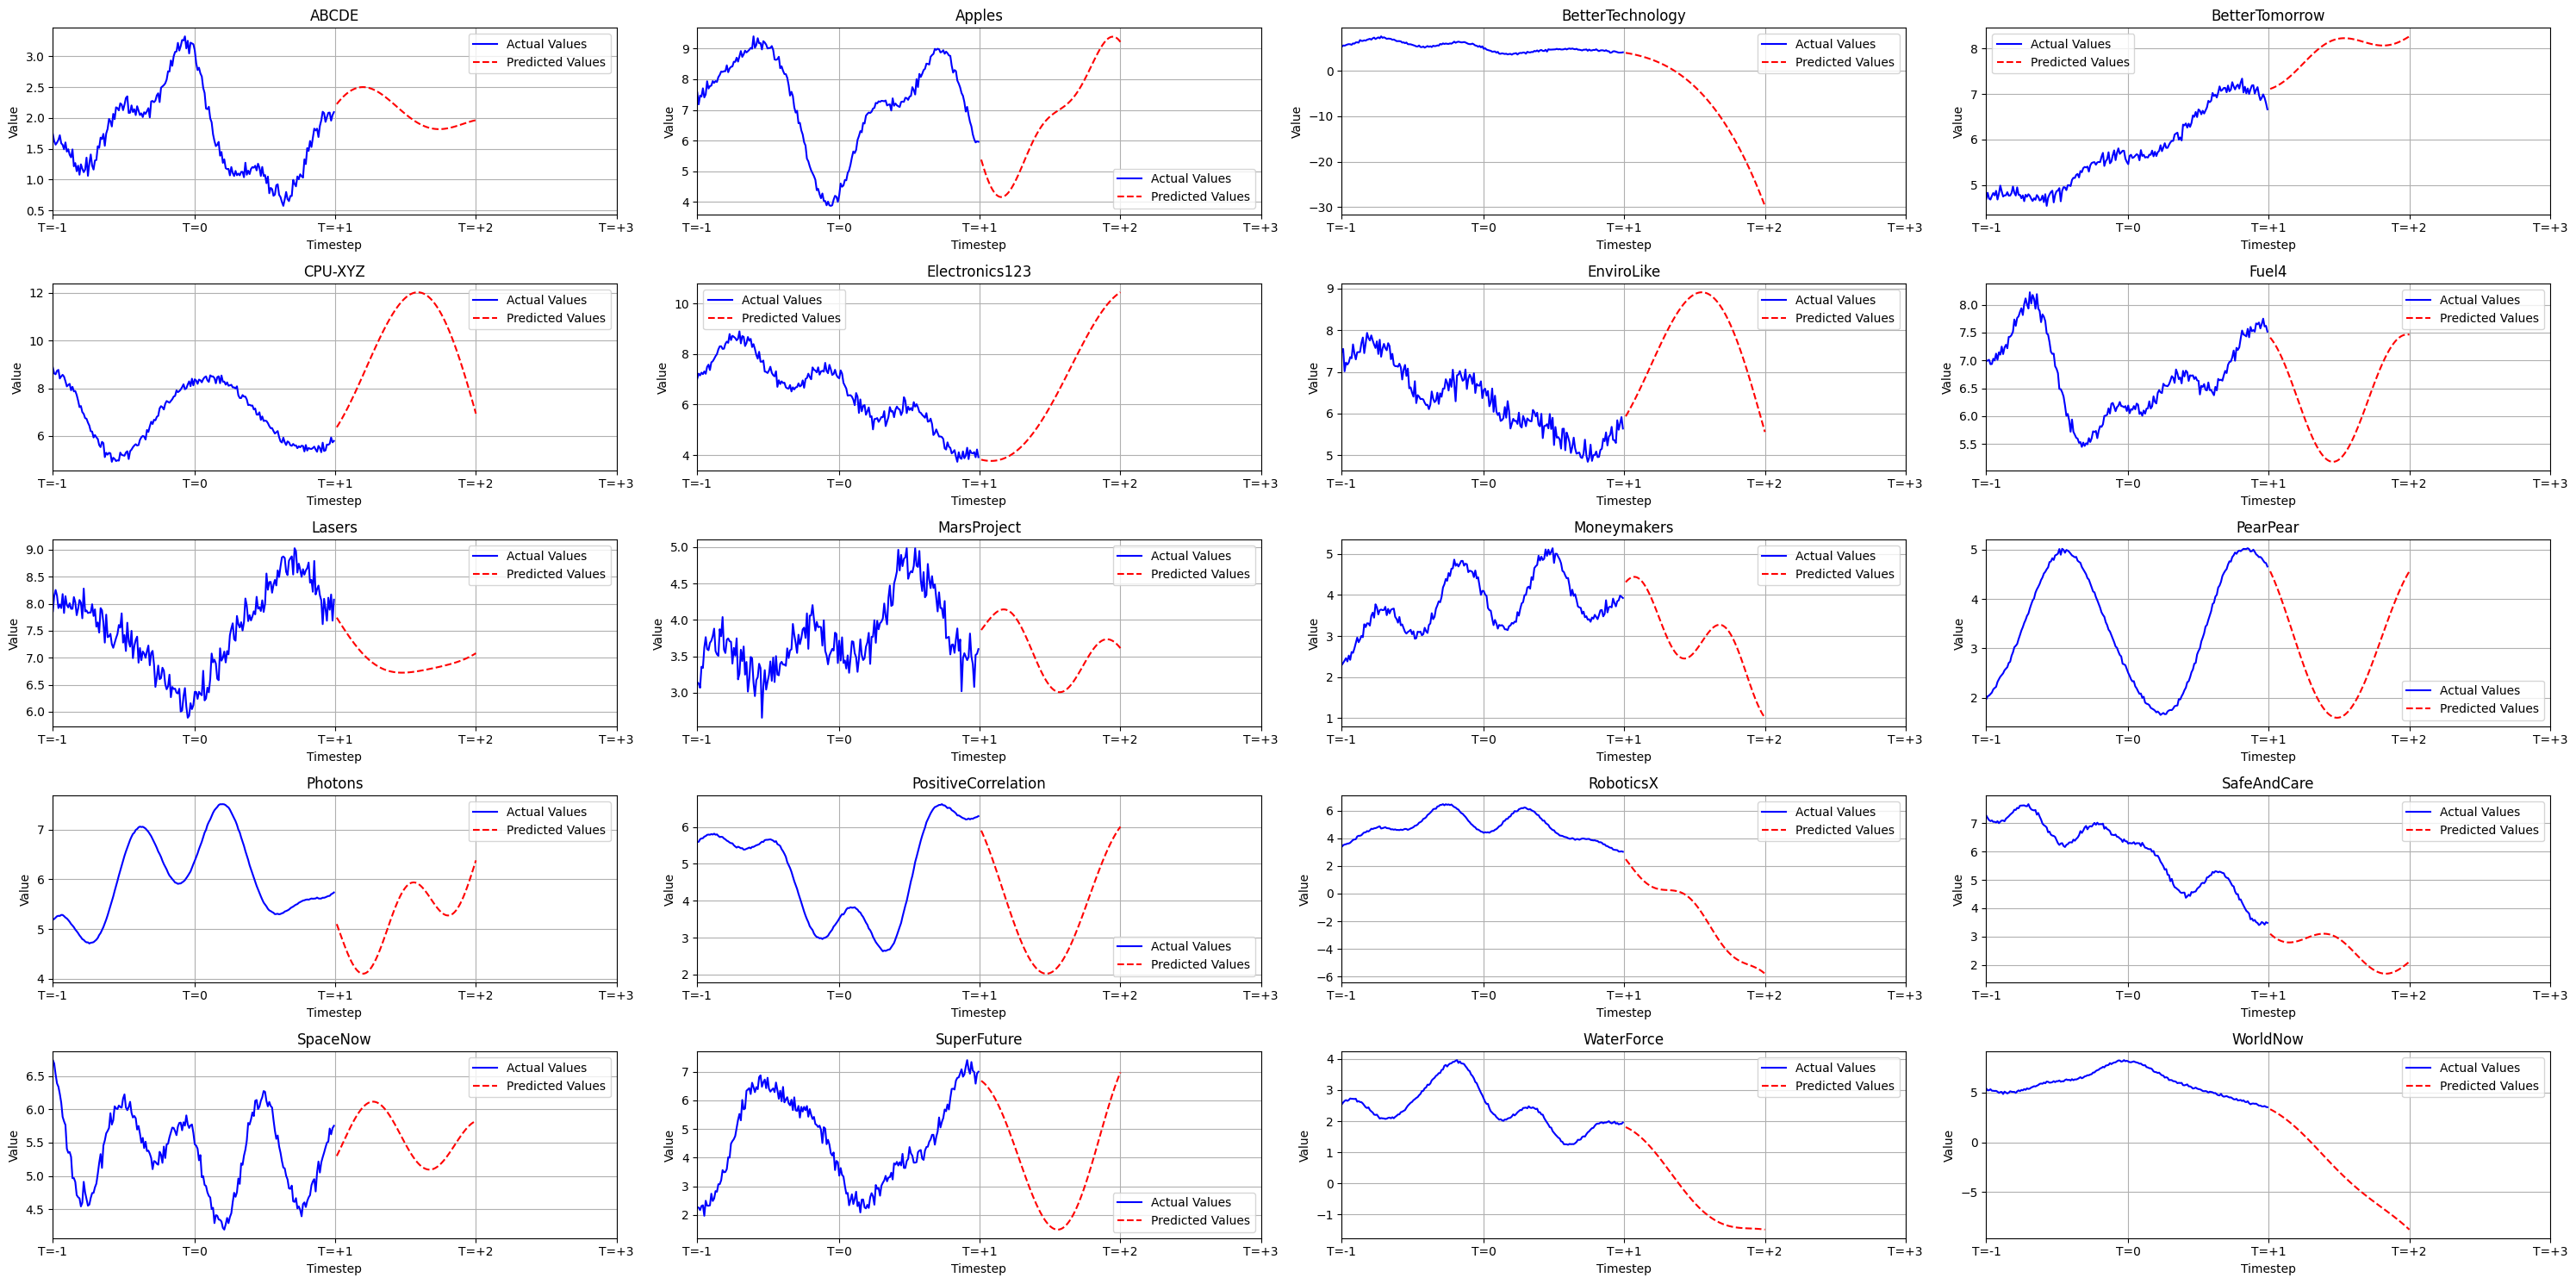

Complex Sinusoidal


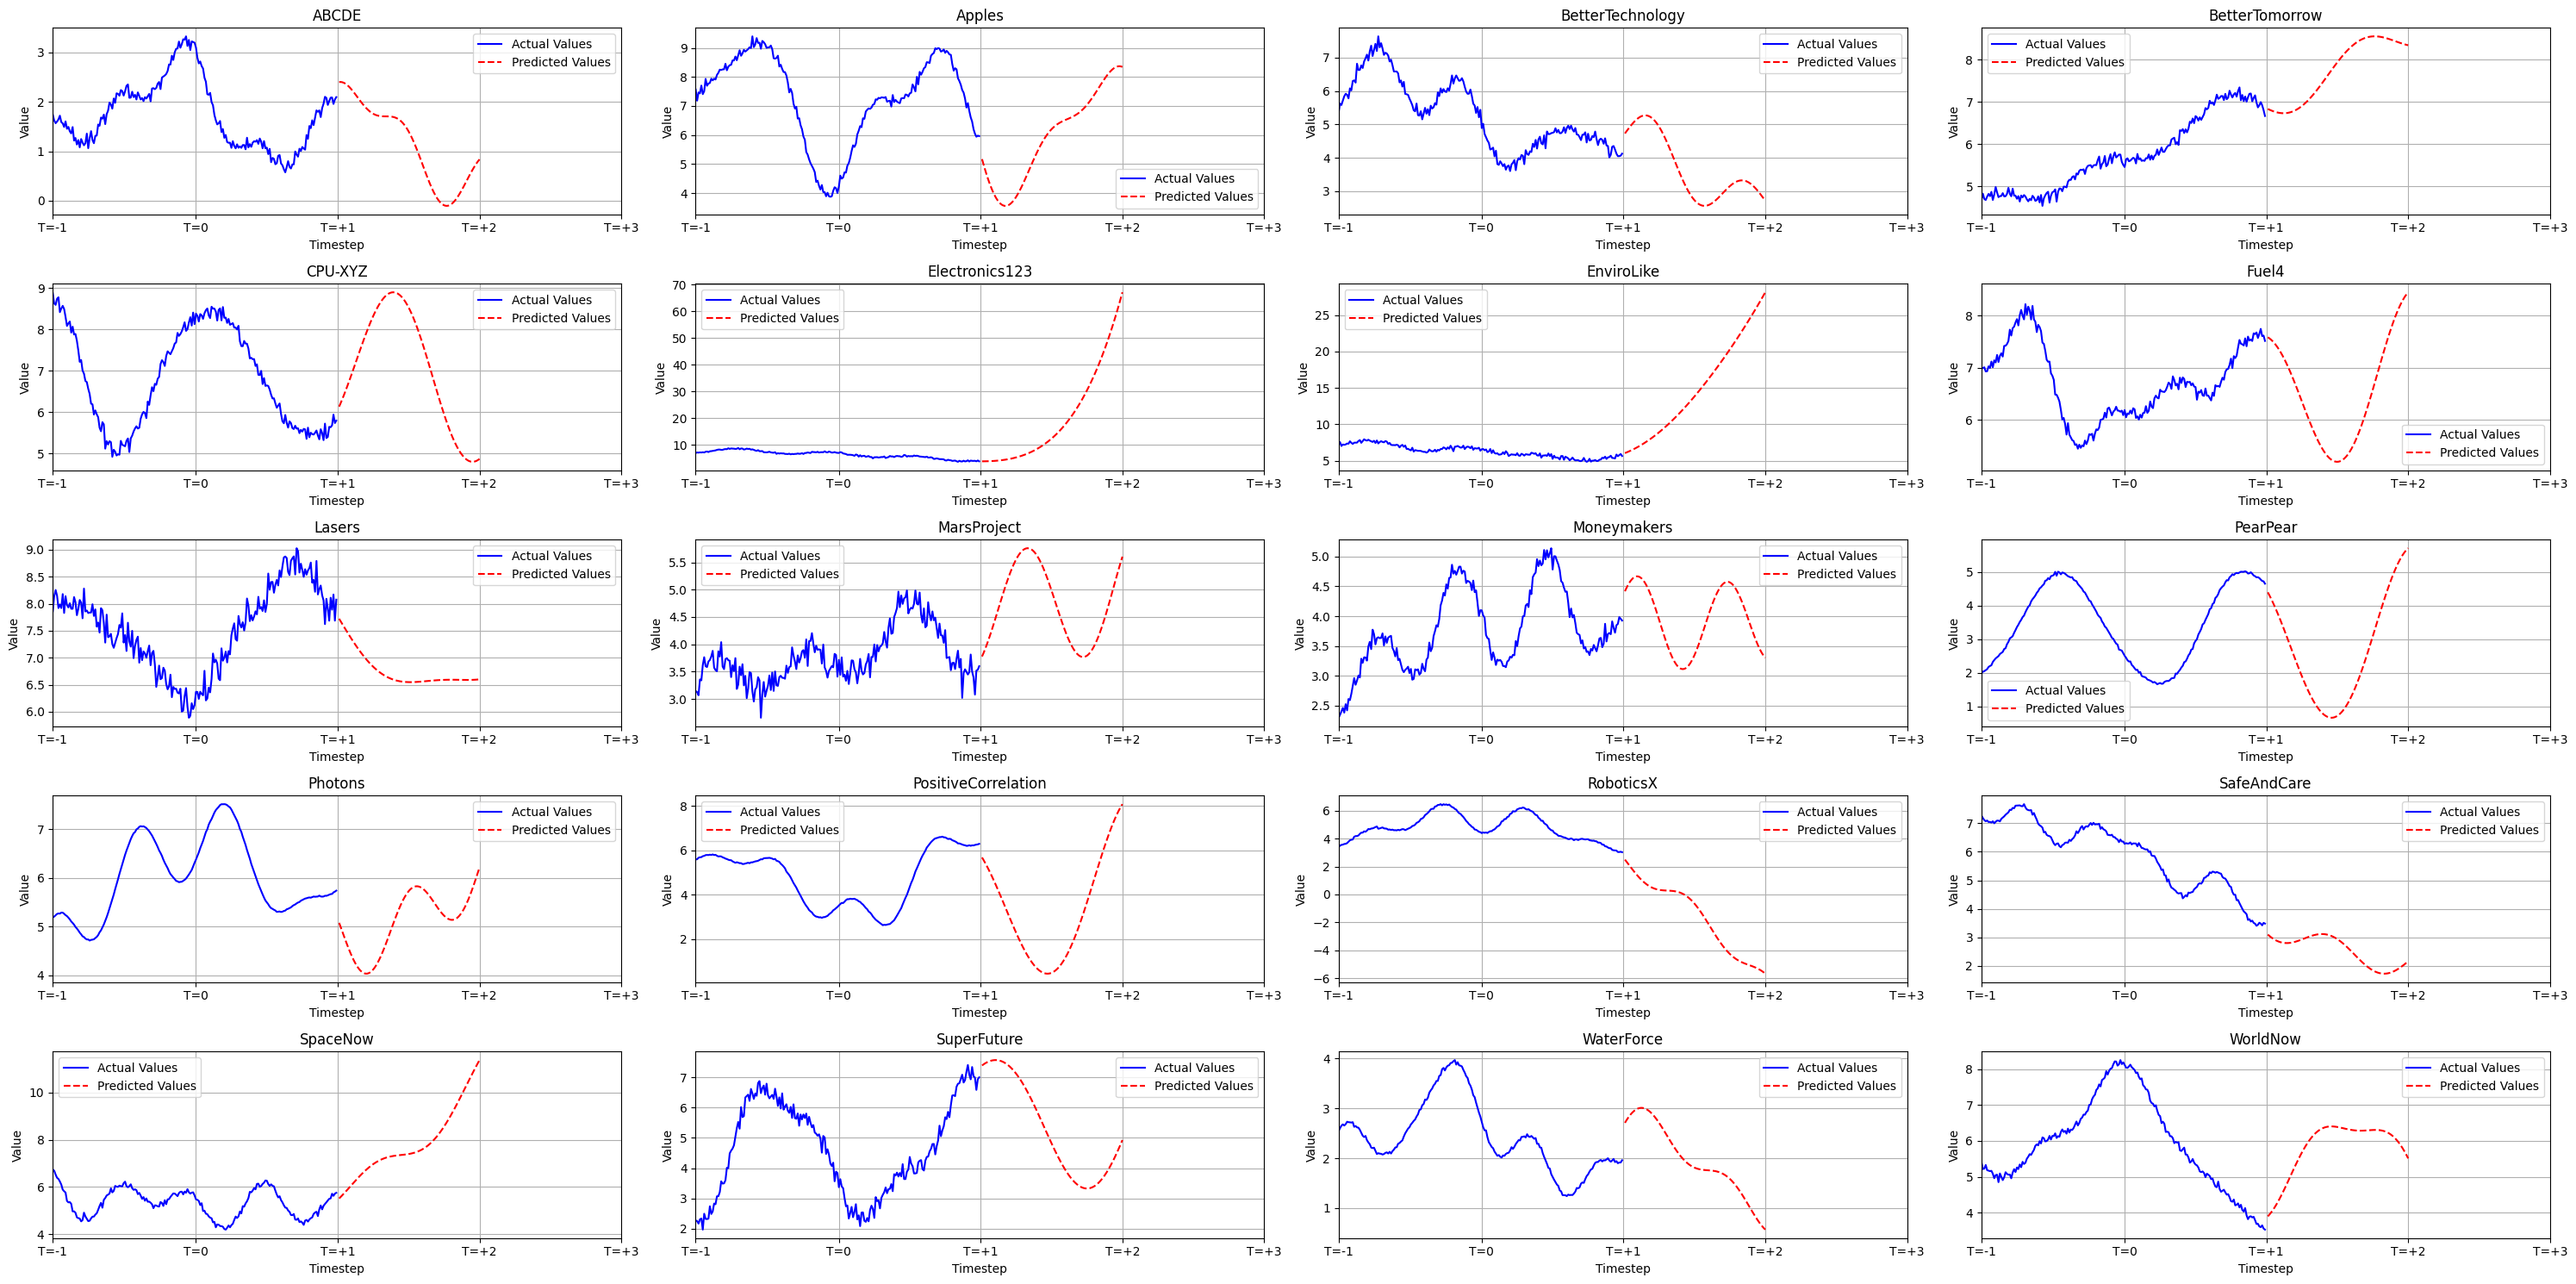

ARIMA


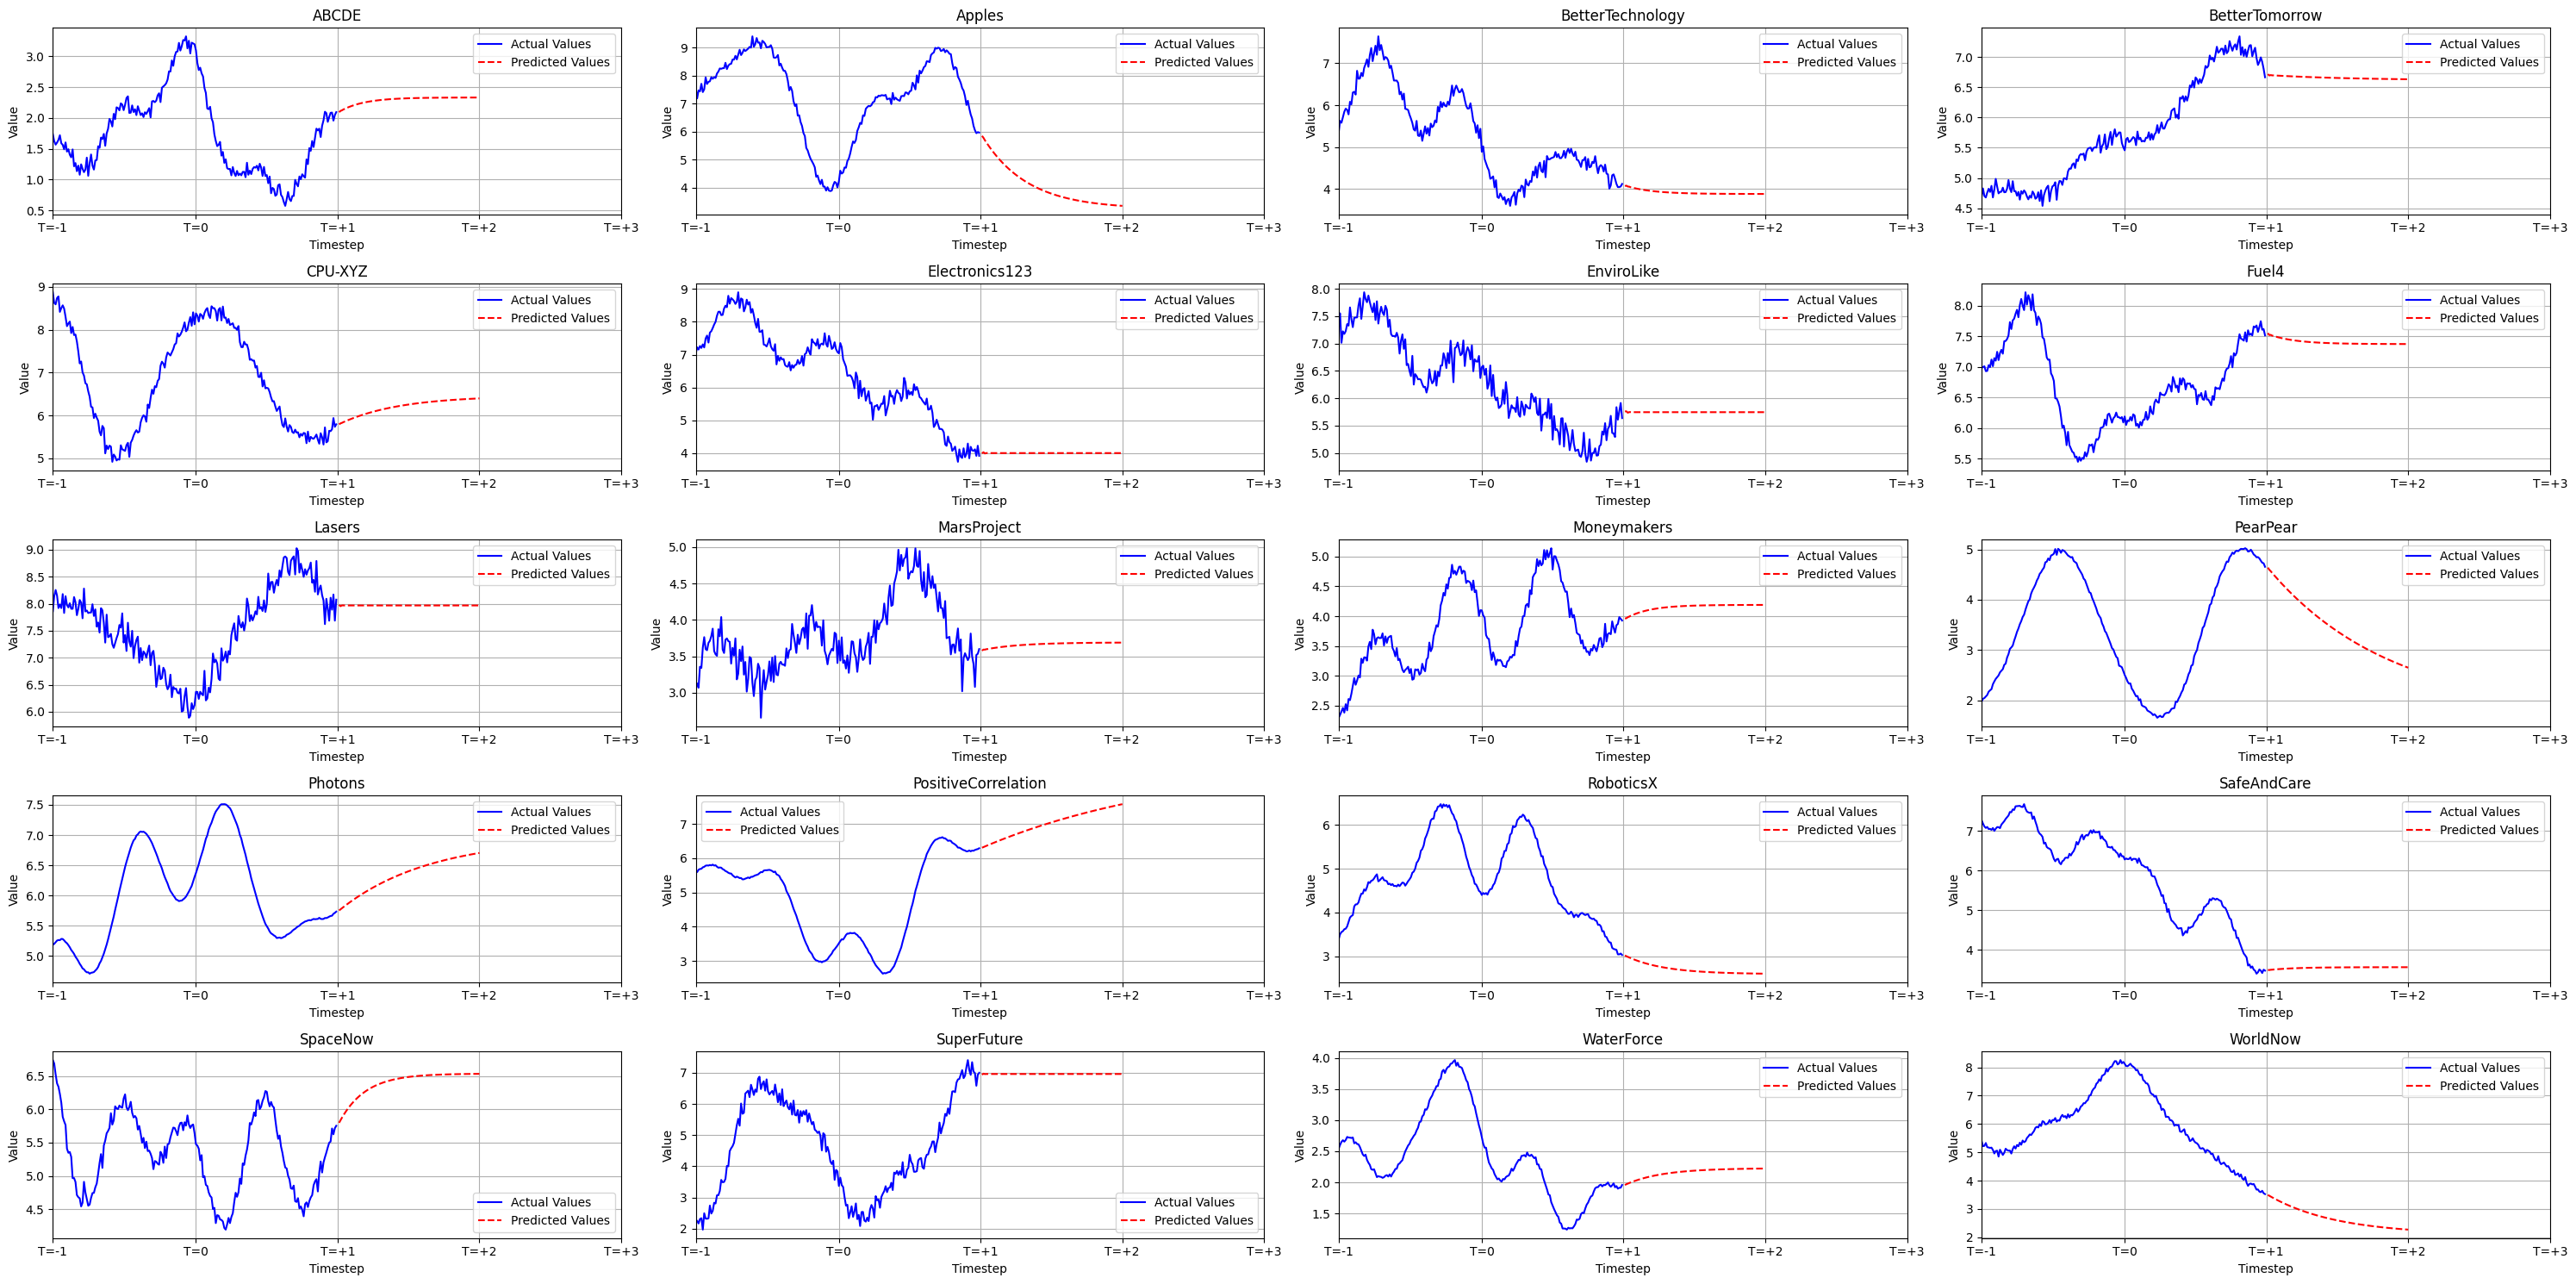

XGBoost


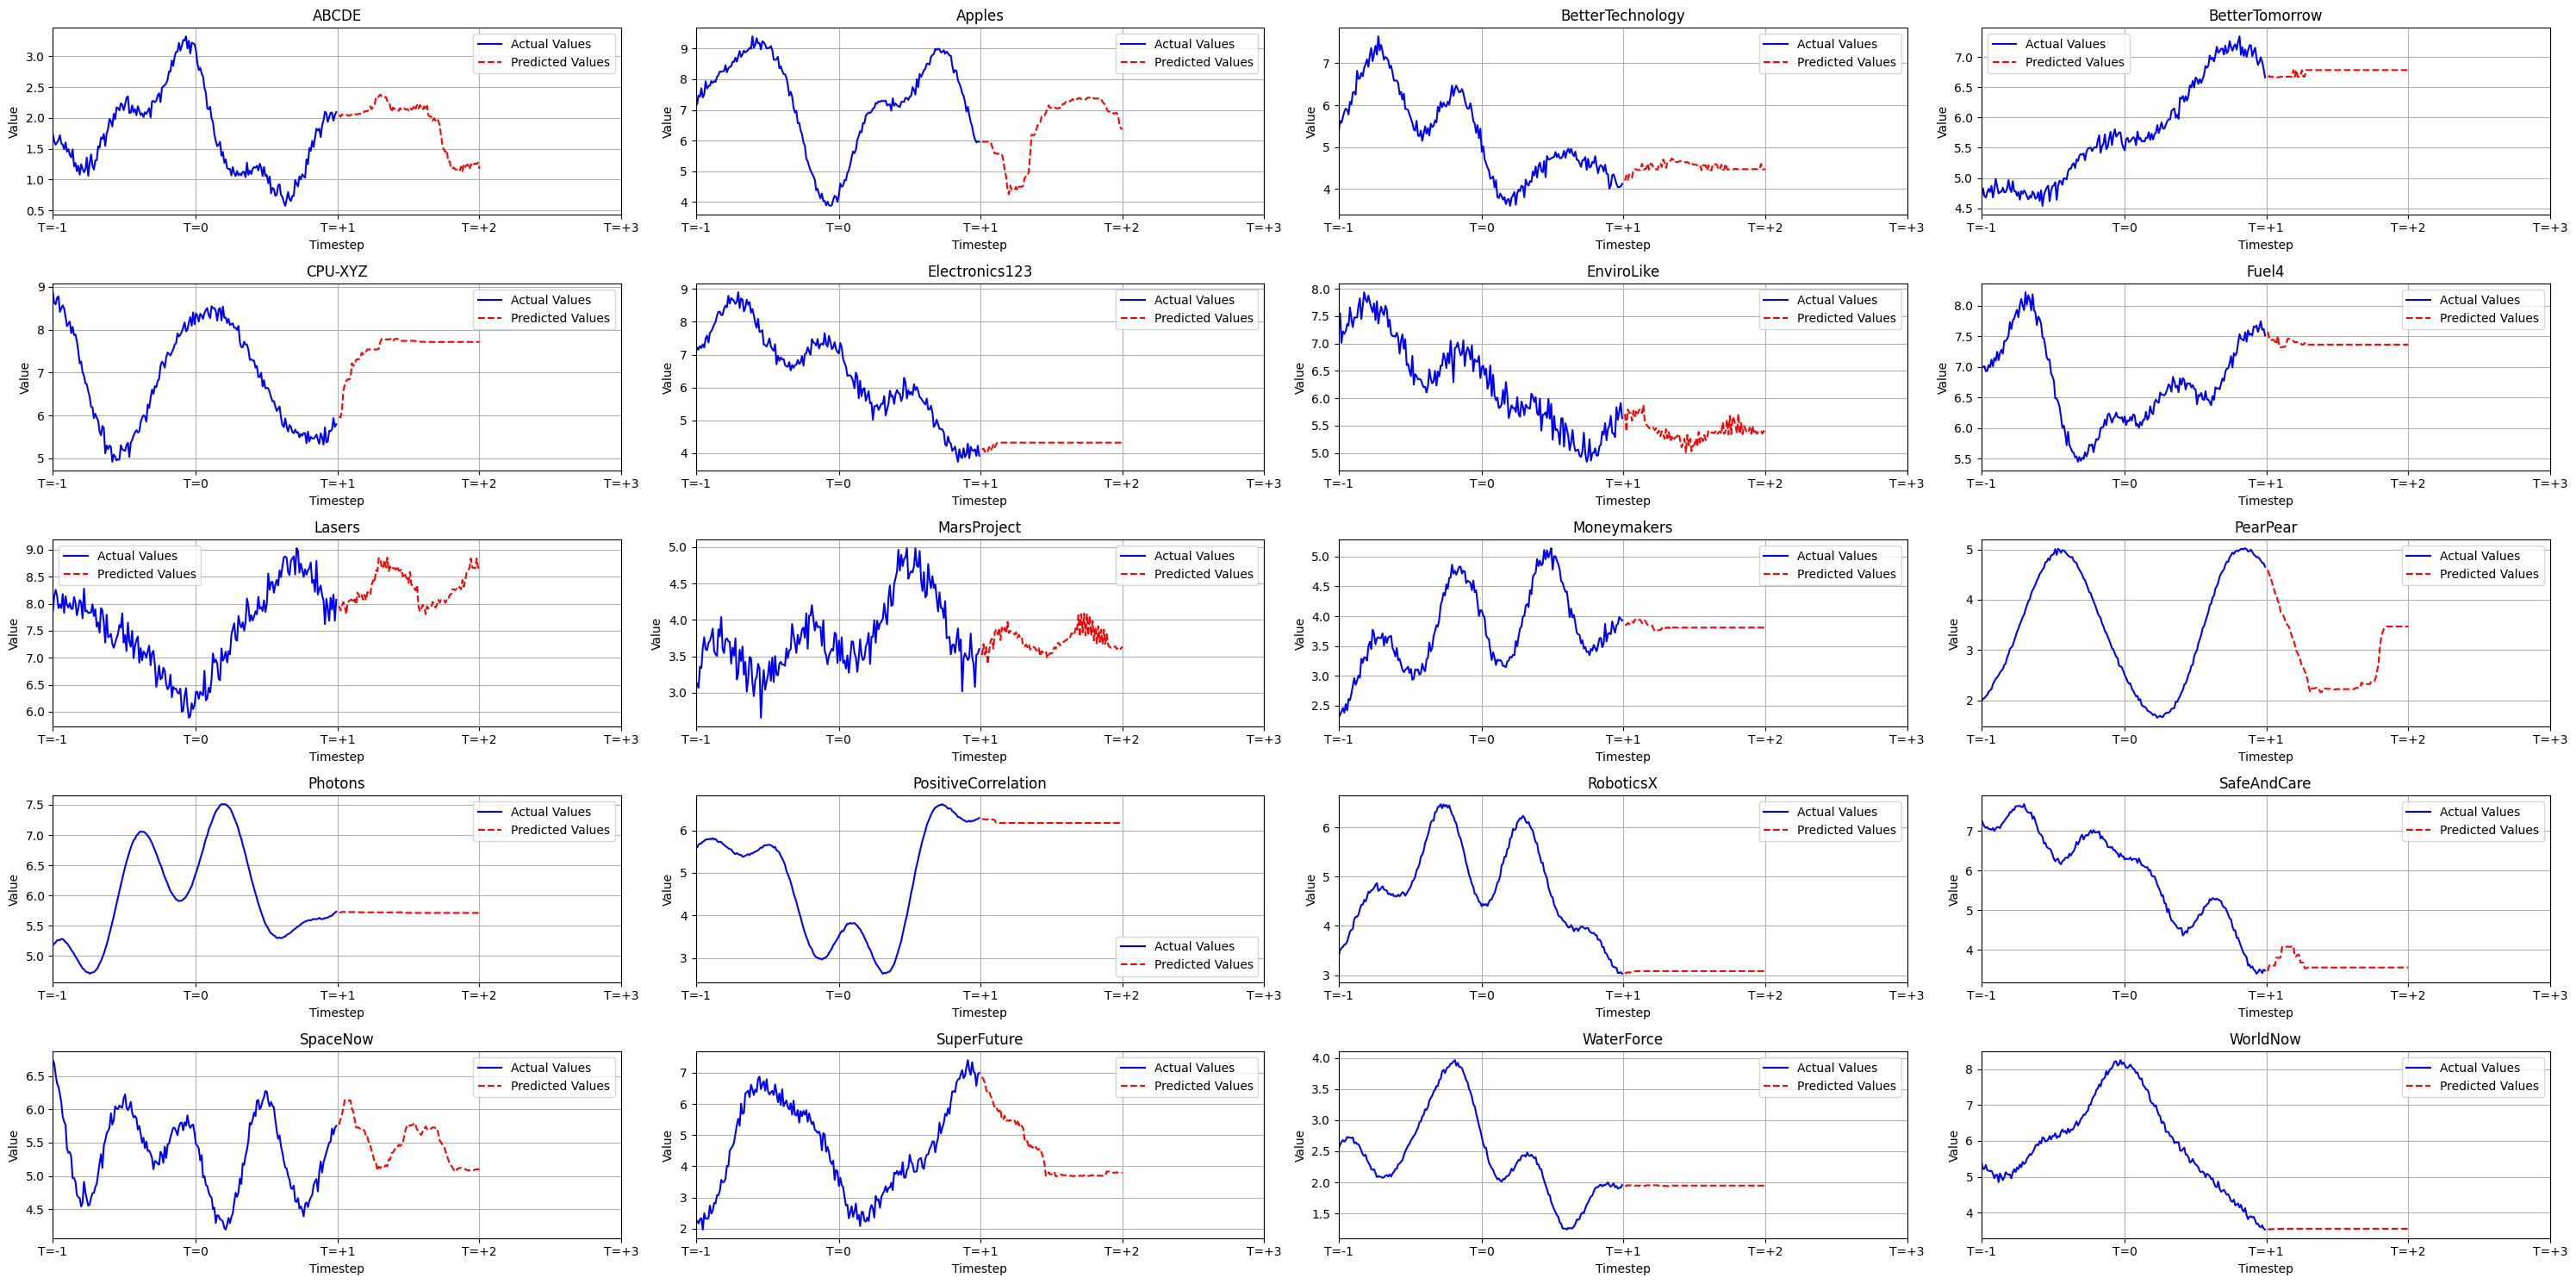

NODE


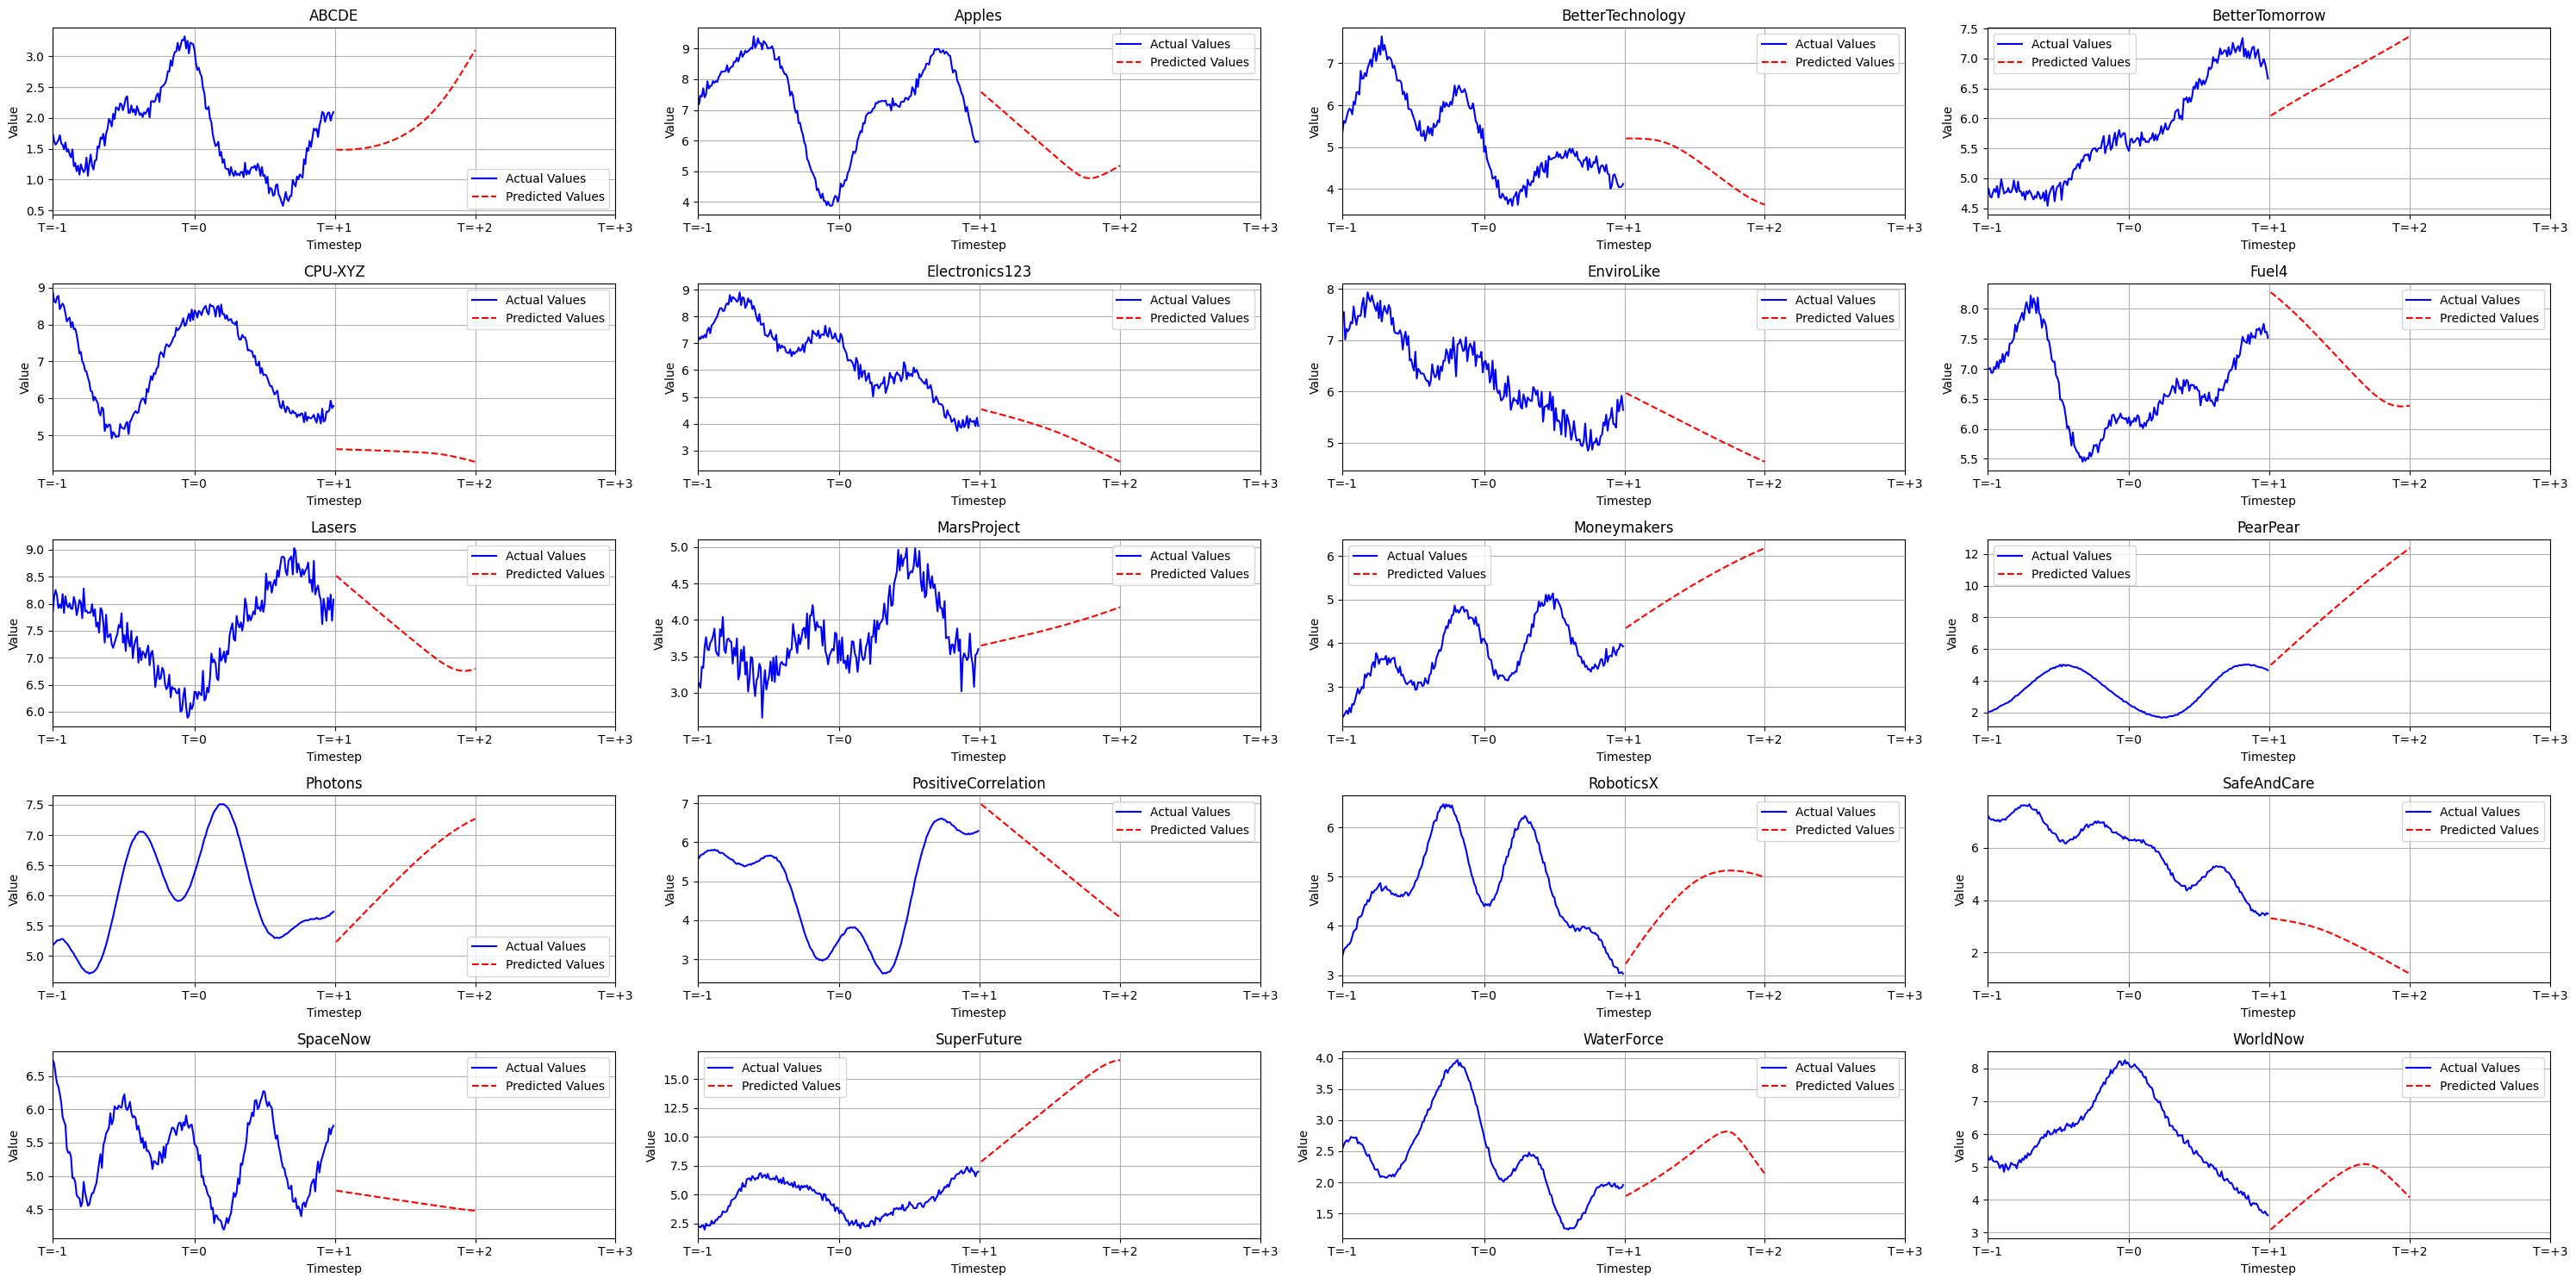

In [8]:
for model in regression_models:
    print(model)
    RMC.plot_predictions(predictions = loaded_data[model], val_range=301, figsize=(30, 15))

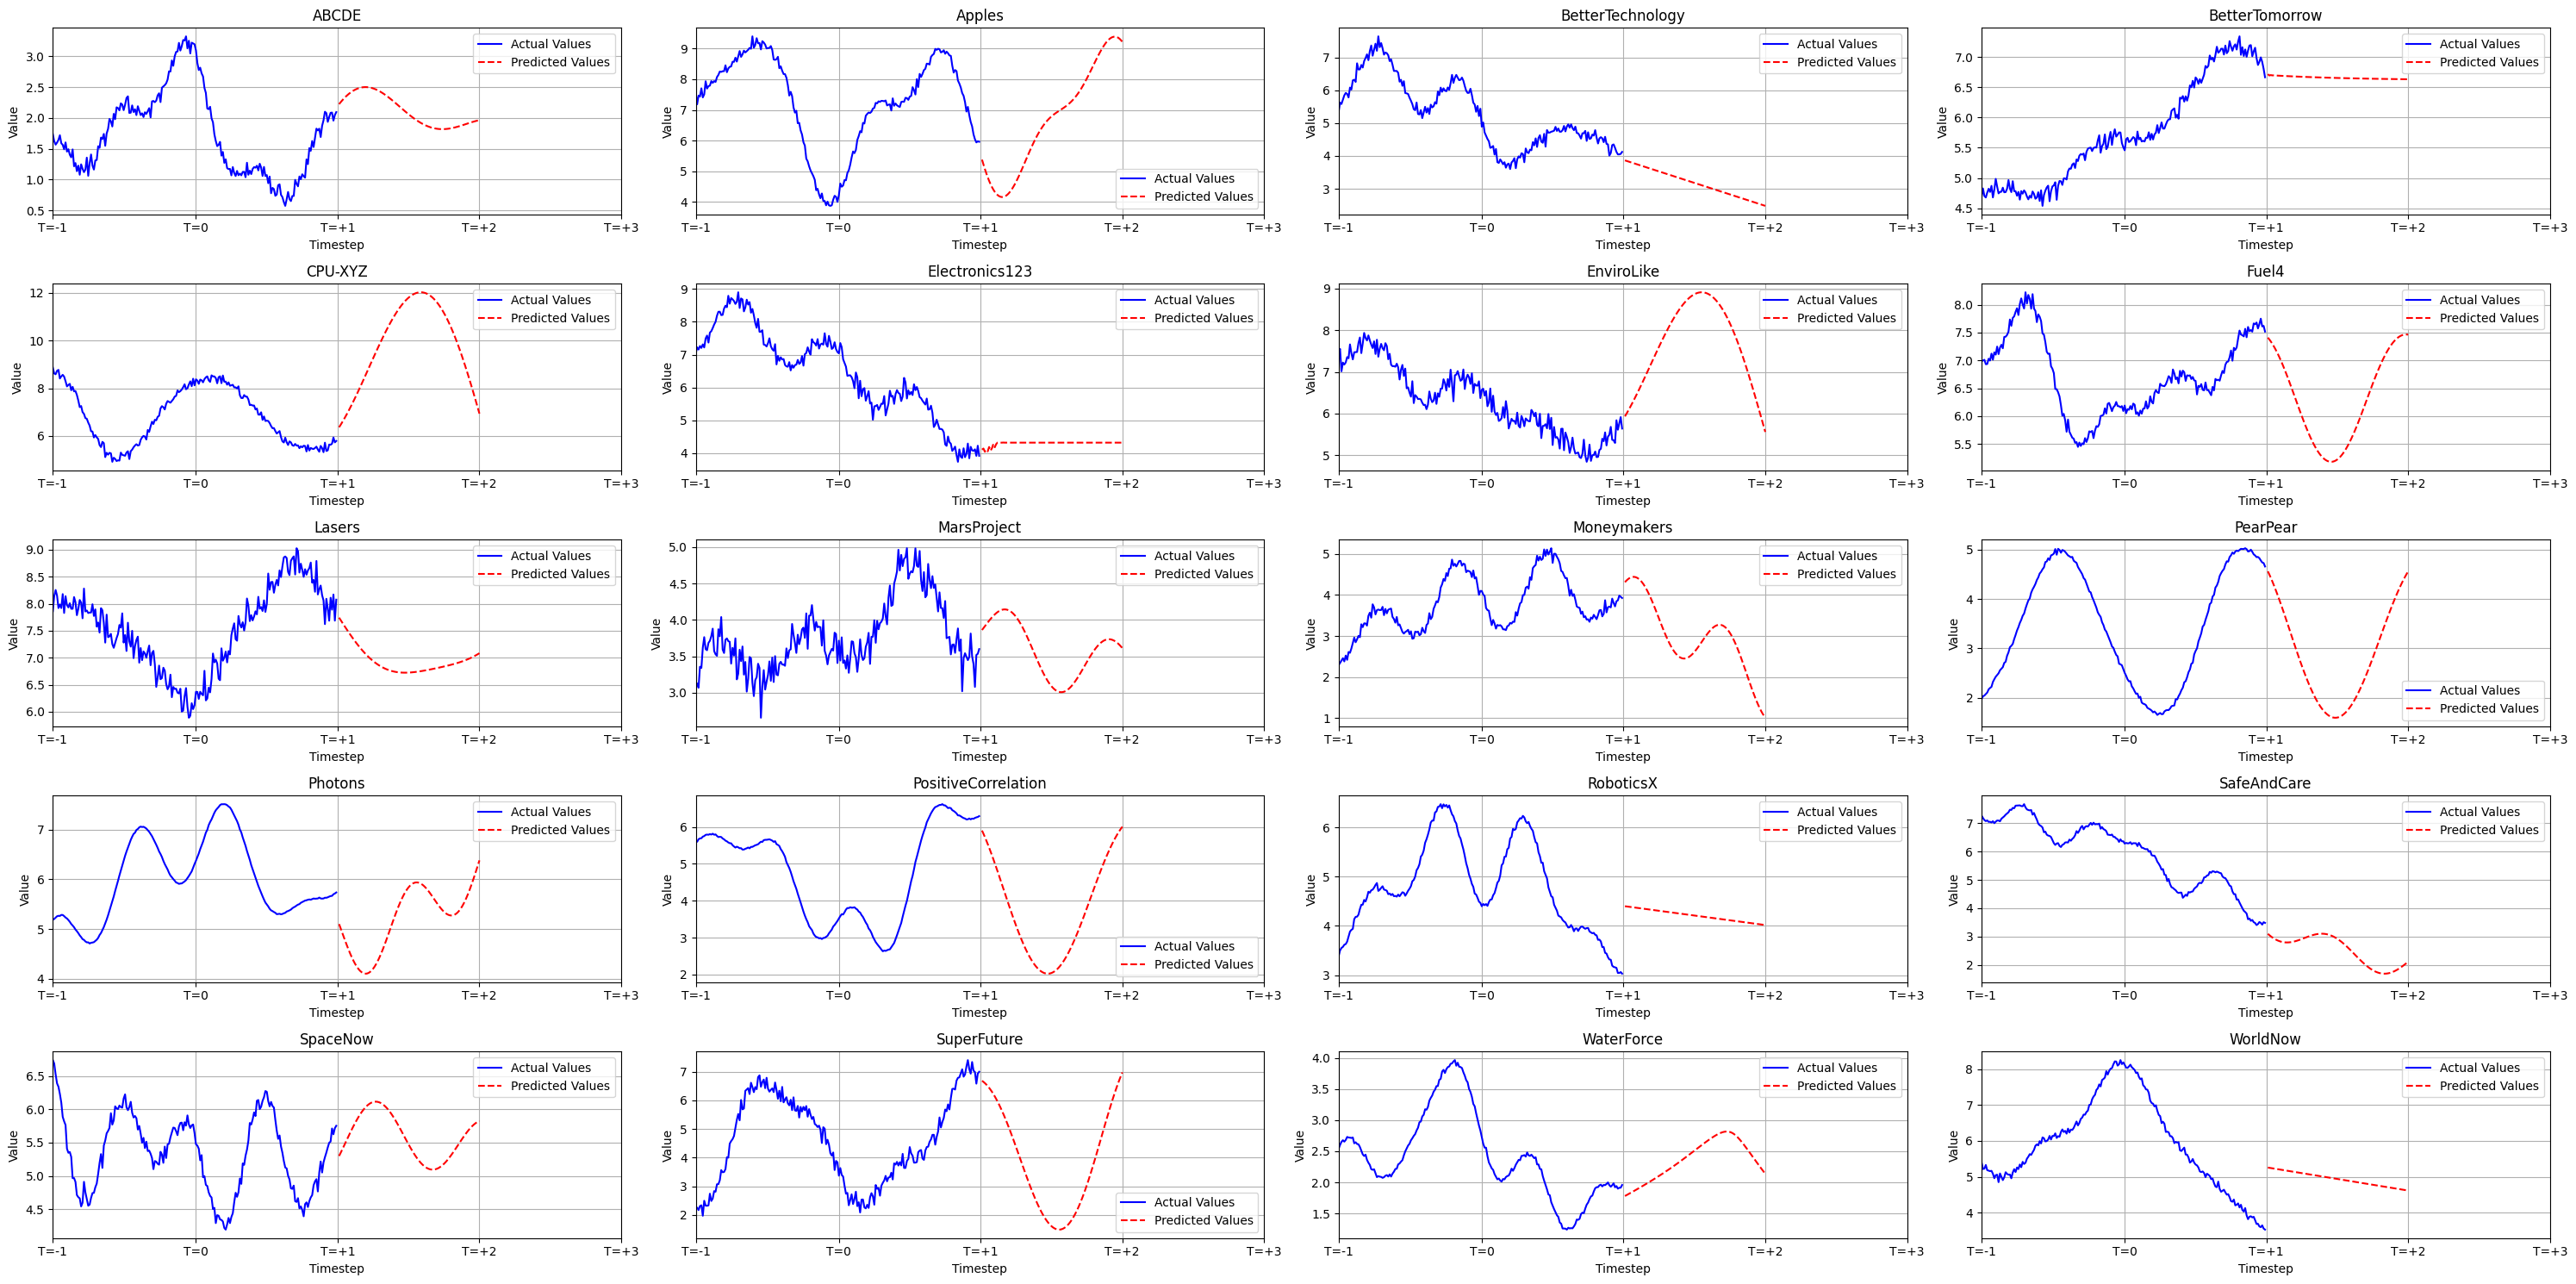

In [9]:
custom_predictions = loaded_data["Sinusoidal"].copy()
custom_predictions["BetterTechnology"] = loaded_data["Linear"]["BetterTechnology"]
custom_predictions["BetterTomorrow"] = loaded_data["ARIMA"]["BetterTomorrow"]
custom_predictions["Electronics123"] = loaded_data["XGBoost"]["Electronics123"]

custom_predictions["RoboticsX"] = loaded_data["Linear"]["RoboticsX"]
custom_predictions["WaterForce"] = loaded_data["NODE"]["WaterForce"]
custom_predictions["WorldNow"] = loaded_data["Linear"]["WorldNow"]

RMC.plot_predictions(predictions = custom_predictions, val_range=301, figsize=(30, 15))

In [10]:
risks = RMC.get_covariance_matrix()
solver = Solver(data, custom_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  4.9673e-03 -2.1598e+01  2e+01  4e-16  8e-16
 1:  3.8359e-03 -6.5040e-01  7e-01  1e-16  1e-15
 2:  9.6364e-04 -2.6848e-02  3e-02  2e-16  1e-16
 3:  5.2762e-04 -3.9347e-03  4e-03  2e-16  1e-16
 4:  4.0403e-04 -1.3624e-04  5e-04  1e-16  2e-16
 5:  3.7763e-04  3.0717e-04  7e-05  2e-16  1e-16
 6:  3.7086e-04  3.6621e-04  5e-06  2e-16  1e-16
 7:  3.7011e-04  3.6995e-04  2e-07  2e-16  2e-16
 8:  3.7005e-04  3.7004e-04  5e-09  2e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -7.2279e-01 -2.8272e+01  1e+02  2e+00  7e-16
 1: -1.7184e-01 -1.1335e+01  1e+01  4e-02  1e-15
 2: -1.5686e-01 -1.3854e+00  1e+00  3e-03  1e-15
 3: -3.9336e-01 -1.2204e+00  8e-01  1e-03  6e-16
 4: -5.2601e-01 -5.7207e-01  5e-02  6e-05  5e-16
 5: -5.4491e-01 -5.4538e-01  5e-04  6e-07  4e-16
 6: -5.4510e-01 -5.4510e-01  5e-06  6e-09  5e-16
 7: -5.4510e-01 -5.4510e-01  5e-08  6e-11  5e-16
Optimal solution found.


Running for w1=0.0, w2=1.0
     pcost       dcost       gap    pres   dres
 0: -1.3704e-01 -2.4126e+01  1e+02  2e+00  9e-16
 1: -3.2004e-02 -8.3669e+00  8e+00  2e-15  2e-15
 2: -4.2189e-02 -9.5986e-01  9e-01  2e-16  1e-15
 3: -1.6927e-01 -8.3734e-01  7e-01  4e-16  6e-16
 4: -2.2098e-01 -2.6906e-01  5e-02  2e-16  3e-16
 5: -2.3840e-01 -2.3890e-01  5e-04  2e-16  2e-16
 6: -2.3858e-01 -2.3858e-01  5e-06  2e-16  3e-16
 7: -2.3858e-01 -2.3858e-01  5e-08  2e-16  2e-16
Optimal solution found.
Running for w1=0.1, w2=0.9
     pcost       dcost       gap    pres   dres
 0: -9.7463e-02 -2.3516e+01  9e+01  2e+00  1e-15
 1: -1.9965e-02 -8.0017e+00  8e+00  8e-16  2e-15
 2: -2.8543e-02 -7.6320e-01  7e-01  1e-16  2e-15
 3: -8.6140e-02 -2.8465e-01  2e-01  1e-16  3e-16
 4: -1.0793e-01 -1.3189e-01  2e-02  2e-16  3e-16
 5: -1.1606e-01 -1.1722e-01  1e-03  1e-16  2e-16
 6: -1.1668e-01 -1.1672e-01  5e-05  2e-16  2e-16
 7: -1.1671e-01 -1.1671e-01  7e-07  2e-16  2e-16
 8: -1.1671e-01 -1.1671e-01  7e-09  1e-16 

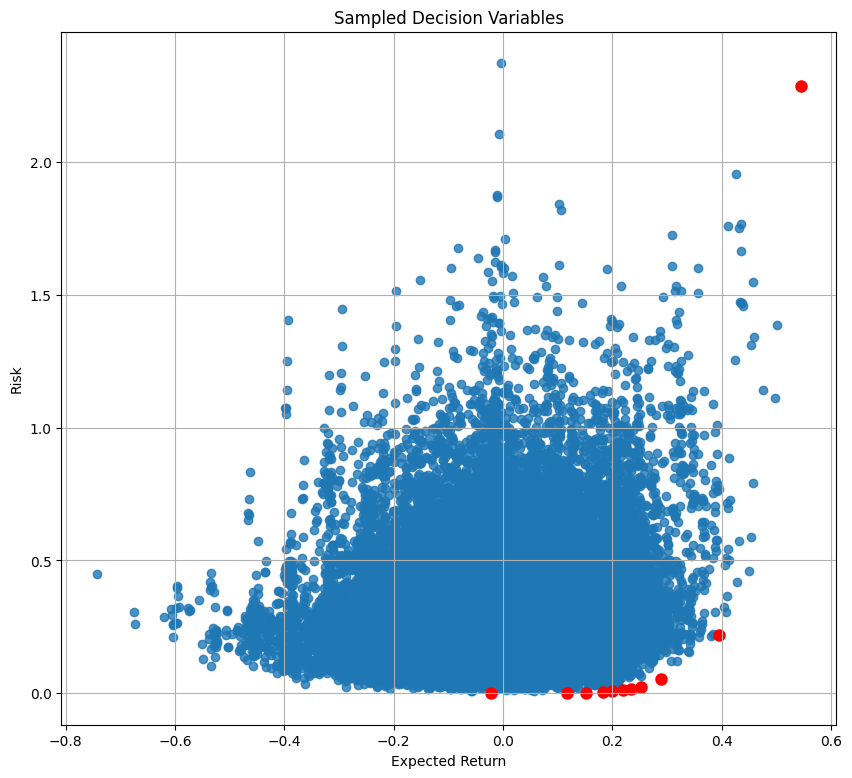

In [11]:
solutions = solver.solve_wsm()
solver.plot_front(solutions, n=20, step=0.2)

Running for threshold=-0.02177772500502704
     pcost       dcost       gap    pres   dres
 0:  5.1481e-03 -2.1672e+01  2e+01  2e-16  2e+00
 1:  4.0089e-03 -6.3386e-01  6e-01  2e-16  7e-02
 2:  9.1817e-04 -2.5850e-02  3e-02  1e-16  2e-03
 3:  5.1332e-04 -2.8562e-03  3e-03  2e-16  2e-04
 4:  4.0839e-04 -1.5432e-04  6e-04  1e-16  3e-05
 5:  3.7579e-04  3.3158e-04  4e-05  2e-16  2e-07
 6:  3.7065e-04  3.6803e-04  3e-06  1e-16  8e-09
 7:  3.7010e-04  3.6998e-04  1e-07  1e-16  1e-10
 8:  3.7005e-04  3.7004e-04  6e-09  2e-16  1e-12
Optimal solution found.
Running for threshold=-0.010208783365537792
     pcost       dcost       gap    pres   dres
 0:  5.0824e-03 -2.1645e+01  2e+01  1e-16  2e+00
 1:  3.9508e-03 -6.3861e-01  6e-01  1e-16  7e-02
 2:  9.2960e-04 -2.6921e-02  3e-02  2e-16  2e-03
 3:  5.1894e-04 -2.8432e-03  3e-03  2e-16  2e-04
 4:  4.1840e-04 -2.9923e-04  7e-04  2e-16  5e-05
 5:  3.7840e-04  3.2564e-04  5e-05  2e-16  1e-16
 6:  3.7209e-04  3.6835e-04  4e-06  2e-16  2e-16
 7:  3.71

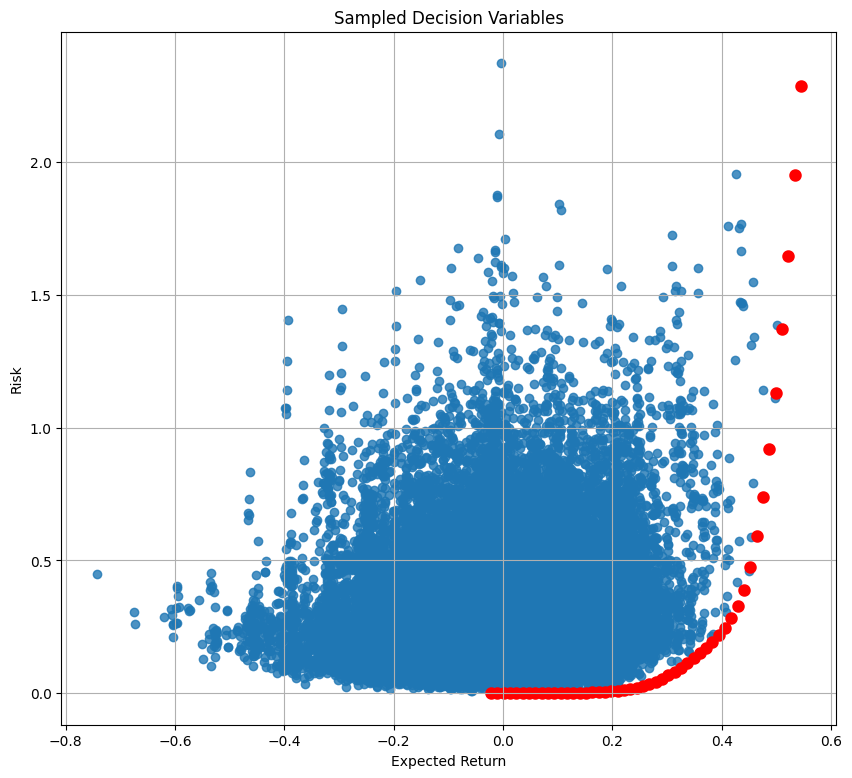

In [14]:
solutions = solver.solve_ecm(50)
solver.plot_front(solutions, n=20, step=0.2)

In [38]:
df = pretty_display(solutions)
df

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,-0.021404,0.000370,3.752097e-08,0.019716,4.751959e-02,1.998257e-03,1.403464e-01,6.597854e-02,3.612224e-08,1.284180e-01,...,9.651950e-02,1.425837e-01,1.593256e-02,8.023476e-02,5.942507e-02,1.433633e-02,6.210386e-05,2.124013e-02,9.585748e-02,1.0
1,-0.010209,0.000371,4.747163e-08,0.017545,5.385574e-02,3.093327e-03,1.305650e-01,6.804982e-02,3.894713e-08,1.355409e-01,...,9.140571e-02,1.448613e-01,1.599425e-02,8.117894e-02,7.026710e-02,1.347669e-02,4.497210e-06,1.424382e-02,9.496501e-02,1.0
2,0.001364,0.000375,2.585038e-06,0.015307,6.042944e-02,4.262704e-03,1.204668e-01,7.016653e-02,1.879323e-06,1.428944e-01,...,8.614887e-02,1.472420e-01,1.605974e-02,8.213146e-02,8.138888e-02,1.258613e-02,8.649202e-05,7.021070e-03,9.405387e-02,1.0
3,0.012932,0.000381,1.617708e-06,0.013095,6.635441e-02,5.595744e-03,1.102030e-01,7.243730e-02,1.654941e-06,1.497769e-01,...,8.051872e-02,1.497016e-01,1.630938e-02,8.289845e-02,9.265992e-02,1.154423e-02,1.804518e-05,6.332018e-04,9.378243e-02,1.0
4,0.024498,0.000391,8.336459e-07,0.011097,6.804207e-02,8.335423e-03,9.894156e-02,7.560241e-02,4.643889e-07,1.533487e-01,...,7.248813e-02,1.529154e-01,1.784661e-02,8.221116e-02,1.042816e-01,9.432869e-03,1.542833e-05,6.100902e-06,9.802278e-02,1.0
5,0.036067,0.000408,1.187733e-06,0.008554,6.845645e-02,1.077153e-02,9.306801e-02,8.053232e-02,2.461995e-07,1.531605e-01,...,5.942793e-02,1.565323e-01,2.101889e-02,8.056856e-02,1.124563e-01,5.695192e-03,1.884352e-06,2.026123e-07,1.069818e-01,1.0
6,0.047636,0.000435,5.638033e-07,0.005890,6.871516e-02,1.312341e-02,8.827549e-02,8.578752e-02,5.487139e-08,1.522946e-01,...,4.541989e-02,1.602166e-01,2.448815e-02,7.875473e-02,1.199399e-01,1.688115e-03,1.422251e-07,1.819138e-08,1.167728e-01,1.0
7,0.059205,0.000472,6.605092e-05,0.002503,6.931976e-02,1.568286e-02,8.363168e-02,9.085708e-02,2.080120e-07,1.507970e-01,...,3.050399e-02,1.637494e-01,2.809884e-02,7.630524e-02,1.273572e-01,5.684152e-05,2.036177e-07,2.405431e-08,1.262765e-01,1.0
8,0.070774,0.000520,1.540419e-03,0.000062,7.009531e-02,1.853055e-02,7.931601e-02,9.489393e-02,8.936261e-08,1.475870e-01,...,1.562617e-02,1.656017e-01,3.187095e-02,7.515302e-02,1.325214e-01,8.345214e-07,4.851584e-08,6.115538e-09,1.356495e-01,1.0
9,0.082344,0.000580,5.022720e-03,0.000025,7.070460e-02,2.159063e-02,7.528048e-02,9.741587e-02,5.808388e-06,1.421841e-01,...,1.745912e-03,1.648675e-01,3.570248e-02,7.660359e-02,1.341825e-01,1.029436e-05,3.346147e-06,4.513590e-07,1.452267e-01,1.0


In [46]:
id = 25
print(df.iloc[id].Risk)
# Print columns in sorted by value order
res = []
for c in df.columns:
    res.append([c, df.iloc[id][c]])

for c, r in sorted(res, key=lambda x: x[1], reverse=True):
    print(c, r)

0.03471969961113587
Sanity Check 1.0
CPU-XYZ 0.28760476983180705
Apples 0.28207285812153887
Expected Gain 0.26744581602278755
WorldNow 0.18692566237622066
SuperFuture 0.12704556378939813
BetterTomorrow 0.1163511380228149
Risk 0.03471969961113587
RoboticsX 1.566245115906005e-09
SpaceNow 1.1764851724239412e-09
WaterForce 9.431231799604546e-10
PearPear 7.658556741892458e-10
MarsProject 6.147085968584243e-10
Fuel4 5.046884499476074e-10
ABCDE 5.01804412947858e-10
PositiveCorrelation 4.6418125141118804e-10
Electronics123 3.034839113413306e-10
EnviroLike 3.0343199153005783e-10
Photons 2.912391447979197e-10
Lasers 2.1462608163728907e-10
BetterTechnology 8.33182159402742e-11
SafeAndCare 6.384896339400587e-11
Moneymakers 6.11802946816701e-11


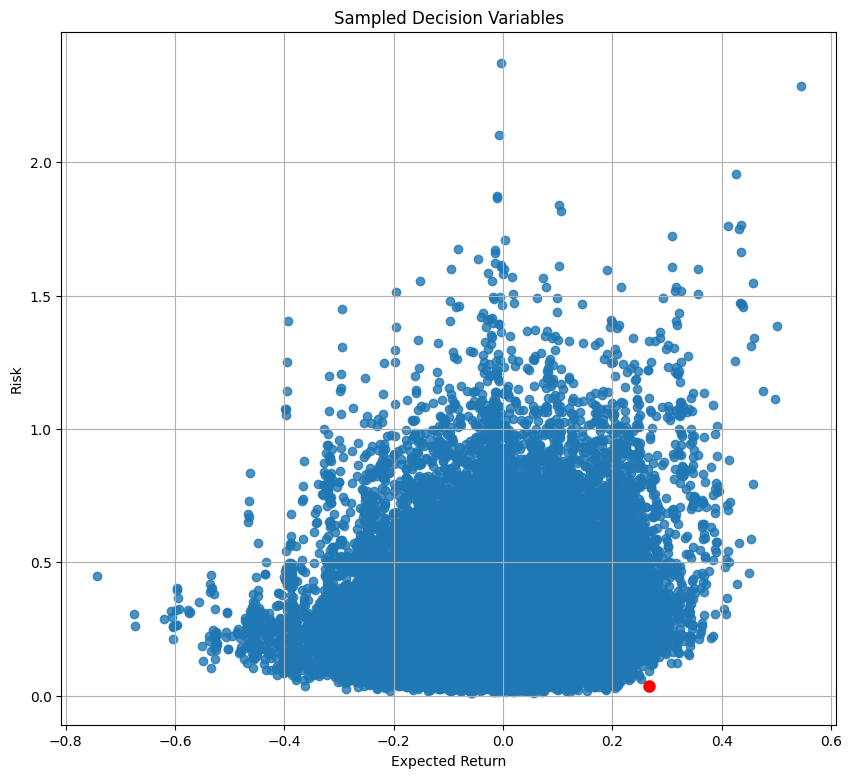

In [47]:
solver.plot_front([solutions[id]])

In [ ]:
def save_solution(df, index, value, filename="151945_151942.txt"):
    if index not in df.index:
        print(f"Error: Index {index} not found in DataFrame.")
        return
    
    row = df.iloc[index]
    expected_total_return = (1.0 + row["Expected Gain"]) * value
    expected_total_risk = row["Risk"]
    weights = [row[company] for company in ORDER]
    solution_line = f"{expected_total_return:.10f} {(100*expected_total_risk):.10f} " + " ".join(f"{w:.10f}" for w in weights)
    with open(filename, "w") as file:
        file.write(solution_line)
    print(f"Solution saved successfully in {filename} with a produced weight sum: {sum(weights)}")



In [ ]:
save_solution(df, id, 100)

Expected Gain          2.674458e-01
Risk                   3.471970e-02
SuperFuture            1.270456e-01
Apples                 2.820729e-01
WorldNow               1.869257e-01
Electronics123         3.034839e-10
Photons                2.912391e-10
SpaceNow               1.176485e-09
PearPear               7.658557e-10
PositiveCorrelation    4.641813e-10
BetterTechnology       8.331822e-11
ABCDE                  5.018044e-10
EnviroLike             3.034320e-10
Moneymakers            6.118029e-11
Fuel4                  5.046884e-10
MarsProject            6.147086e-10
CPU-XYZ                2.876048e-01
RoboticsX              1.566245e-09
Lasers                 2.146261e-10
WaterForce             9.431232e-10
SafeAndCare            6.384896e-11
BetterTomorrow         1.163511e-01
Sanity Check           1.000000e+00
Name: 25, dtype: float64